# Beauty Industry: Makeup Products — Price vs Rating Performance and Price, Quality & Green Claims
## Lisa, Eliram, and Judi
### Tool: SQLite via Python (sqlite3 + pandas), numpy, requests, matplotlib, seaborn, sklearn

### INTRODUCTION
#### Motivation
The global beauty market offers consumers a wide range of products that vary widely in price, often marketed under the premise that a higher cost directly correlates with superior quality. For consumer, this "Luxury Marker" is a primary driver in decision-making. However, it remains unclear if these premium prices reflect actual consumer satisfaction or if they are merely a byproduct of aggressive marketing strategies, such as linguisitc complexity in its product descriptions and eco-friendly, "green" claims. 

#### Objective
This project, then, leverages the Makeup API (http://makeup-api.herokuapp.com/api/v1/products.json) and supplemental datasets to investigate the relationship between product pricing, user ratings, and marketing language surrounding the cosmetics industry. Our analysis soecifically seeks to:

1. Determine the correlation between price and user ratings across different product categories.
2. Evaluate the "Description Premium" by analyzing whether longer, more complex description are used to justify higher price tiers.
3. Investigate 'Green Marketing' patterns to identify potential "greenwashing" by examining common tokens that signal eco-friendliness vs actual product certifications.

Finally, we aim to provide predictions through regression models on 1. products rated above their product-type average based on features such as price and description length. And 2. price prediction based on quality and select marketing characteristics.

#### Target Audience
This project is designed for value-driven consumers looking to navigate marketing hype, environmentally-concious consumer monitoring greenwashing trends, and cosmetic brand managers that might be seeking data-backed insight into market positioning. 

#### Practical Usefulness
When shopping for makeup in retail settings such as Sephora, consumers are often encouraged to purchase higher-priced products under the assumption that more expensive items are of higher quality. Sales associates frequently frame premium products as superior, implicitly suggesting that price is a reliable signal of performance. For consumers trying to make informed purchasing decisions, this raises a natural question: are more expensive makeup products actually better?

Using product-level data from a public makeup API, our analysis helps consumers identify when they are paying for marketing fluff versus actual performance. A consumer can use our analysis to look at a high-priced product's description and ask: "Am I paying for these fancy words, or does the rating actually back up the price?"

Furthermore, this project shows how to benchmark a product against the competition. For example, if a brand wants to launch a "Luxury" foundation, they can use this analysis to see the "linguistic standard" for that tier. In other words, if most luxury foundations have a word count of 120+, a 30-word description might make their product look "cheap" to a high-end buyer (this example could be extrapolated to the case of eco-friendly products to detect potential "greenwashing").

### Preliminary analysis: Price and Ratings Performance
**Note_Fixing:** Unusual quantitative values observed, but no exploratory analysis/resolution is provided for the issue      

In [3]:
import requests
import pandas as pd
import numpy as np

In [4]:
#setting a limit in the number of columns to display, and the screen width
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 1200)

In [5]:
# pull data from the Makeup API
# http://makeup-api.herokuapp.com/api/v1/products.json
BASE_URL = "http://makeup-api.herokuapp.com/api/v1/products.json"

In [6]:
# pull all products at once 
resp = requests.get(BASE_URL, timeout=30)
resp.raise_for_status() 

In [7]:
data_json = resp.json()  # list of dictionaries
print("Number of records pulled:", len(data_json))
print("Sample keys:", list(data_json[0].keys()))

Number of records pulled: 931
Sample keys: ['id', 'brand', 'name', 'price', 'price_sign', 'currency', 'image_link', 'product_link', 'website_link', 'description', 'rating', 'category', 'product_type', 'tag_list', 'created_at', 'updated_at', 'product_api_url', 'api_featured_image', 'product_colors']


In [8]:
# Convert to DataFrame: df_raw. .head() First five elements to see all categories
df_raw = pd.DataFrame(data_json)
df_raw.head()

,id,brand,name,price,price_sign,currency,image_link,product_link,website_link,description,rating,category,product_type,tag_list,created_at,updated_at,product_api_url,api_featured_image,product_colors
0,1048,colourpop,Lippie Pencil,5.0,$,CAD,https://cdn.shopify.com/s/files/1/1338/0845/co...,https://colourpop.com/collections/lippie-pencil,https://colourpop.com,Lippie Pencil A long-wearing and high-intensit...,NaN,pencil,lip_liner,"[cruelty free, Vegan]",2018-07-08T23:45:08.056Z,2018-07-09T00:53:23.301Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,"[{'hex_value': '#B28378', 'colour_name': 'BFF ..."
1,1047,colourpop,Blotted Lip,5.5,$,CAD,https://cdn.shopify.com/s/files/1/1338/0845/pr...,https://colourpop.com/collections/lippie-stix?...,https://colourpop.com,Blotted Lip Sheer matte lipstick that creates ...,NaN,lipstick,lipstick,"[cruelty free, Vegan]",2018-07-08T22:01:20.178Z,2018-07-09T00:53:23.287Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,"[{'hex_value': '#b72227', 'colour_name': 'Bee'..."
2,1046,colourpop,Lippie Stix,5.5,$,CAD,https://cdn.shopify.com/s/files/1/1338/0845/co...,https://colourpop.com/collections/lippie-stix,https://colourpop.com,"Lippie Stix Formula contains Vitamin E, Mango,...",NaN,lipstick,lipstick,"[cruelty free, Vegan]",2018-07-08T21:47:49.858Z,2018-07-09T00:53:23.274Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,"[{'hex_value': '#F2DEC3', 'colour_name': 'Fair..."
3,1045,colourpop,No Filter Foundation,12.0,$,CAD,https://cdn.shopify.com/s/files/1/1338/0845/pr...,https://colourpop.com/products/no-filter-matte...,https://colourpop.com/products/no-filter-matte...,"Developed for the Selfie Age, our buildable fu...",NaN,liquid,foundation,"[cruelty free, Vegan]",2018-07-08T18:22:25.273Z,2018-07-09T00:53:23.313Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,"[{'hex_value': '#F2DEC3', 'colour_name': 'Fair..."
4,1044,boosh,Lipstick,26.0,$,CAD,https://cdn.shopify.com/s/files/1/1016/3243/pr...,https://www.boosh.ca/collections/all,https://www.boosh.ca/,All of our products are free from lead and hea...,NaN,lipstick,lipstick,"[Chemical Free, Organic]",2018-07-08T17:32:28.088Z,2018-09-02T22:52:06.669Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,"[{'hex_value': '#CB4975', 'colour_name': 'Babs..."


In [9]:
# Quick sanity checks (API + structure)
df_raw.shape, df_raw.columns

((931, 19),
 Index(['id', 'brand', 'name', 'price', 'price_sign', 'currency', 'image_link', 'product_link', 'website_link', 'description', 'rating', 'category', 'product_type', 'tag_list', 'created_at', 'updated_at', 'product_api_url', 'api_featured_image', 'product_colors'], dtype='str'))

In [10]:
# pull only a subset (dictionary)
params = {
    "brand": "maybelline",
    # "product_type": "lipstick"
}

resp2 = requests.get(BASE_URL, params=params, timeout=30)
print(resp2.status_code) #checks error status, tells us if 2XX, 4XX, or 5XX

200


In [11]:
data_json2 = resp2.json()

df_maybelline = pd.DataFrame(data_json2)
print("Maybelline rows:", df_maybelline.shape[0])
df_maybelline.head() #head method for Maybelline

Maybelline rows: 54


,id,brand,name,price,price_sign,currency,image_link,product_link,website_link,description,rating,category,product_type,tag_list,created_at,updated_at,product_api_url,api_featured_image,product_colors
0,495,maybelline,Maybelline Face Studio Master Hi-Light Light B...,14.99,None,None,https://d3t32hsnjxo7q6.cloudfront.net/i/991799...,https://well.ca/products/maybelline-face-studi...,https://well.ca,Maybelline Face Studio Master Hi-Light Light B...,5.0,NaN,bronzer,[],2016-10-01T18:36:15.012Z,2017-12-23T21:08:50.624Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,[]
1,488,maybelline,Maybelline Fit Me Bronzer,10.29,None,None,https://d3t32hsnjxo7q6.cloudfront.net/i/d4f7d8...,https://well.ca/products/maybelline-fit-me-bro...,https://well.ca,Why You'll Love It\n\nLightweight pigments ble...,4.5,NaN,bronzer,[],2016-10-01T18:36:05.584Z,2017-12-23T21:08:49.985Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,"[{'hex_value': '#CF9978', 'colour_name': 'Medi..."
2,477,maybelline,Maybelline Facestudio Master Contour Kit,15.99,None,None,https://d3t32hsnjxo7q6.cloudfront.net/i/4f731d...,https://well.ca/products/maybelline-facestudio...,https://well.ca,Maybelline Facestudio Master Contour Kit is th...,NaN,NaN,bronzer,[],2016-10-01T18:35:40.504Z,2017-12-23T21:08:48.157Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,"[{'hex_value': '#9B7163', 'colour_name': None}..."
3,468,maybelline,Maybelline Face Studio Master Hi-Light Light B...,14.99,None,None,https://d3t32hsnjxo7q6.cloudfront.net/i/462103...,https://well.ca/products/maybelline-face-studi...,https://well.ca,Maybelline Face Studio Master Hi-Light Light B...,NaN,powder,blush,[],2016-10-01T18:35:27.706Z,2017-12-23T21:08:47.102Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,[]
4,452,maybelline,Maybelline Face Studio Master Hi-Light Light B...,14.99,None,None,https://d3t32hsnjxo7q6.cloudfront.net/i/e8c59b...,https://well.ca/products/maybelline-face-studi...,https://well.ca,Maybelline Face Studio Master Hi-Light Light B...,5.0,powder,blush,[],2016-10-01T18:35:07.476Z,2017-12-23T20:51:17.460Z,http://makeup-api.herokuapp.com/api/v1/product...,//s3.amazonaws.com/donovanbailey/products/api_...,[]


In [139]:
# Missing data check
missing_count = df_raw.isna().sum() #isna #sum 
missing_pct = (df_raw.isna().mean() * 100).round(2) #mean

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

missing_summary.head(10)

,missing_count,missing_pct
rating,591,63.48
price_sign,563,60.47
currency,563,60.47
category,414,44.47
price_num,14,1.50
price,14,1.50
brand,12,1.29
description,1,0.11
name,0,0.00
id,0,0.00


We observe substantial missingness in the rating variable, with over 60% of products lacking consumer ratings. This pattern is expected in product-level consumer data, as many items may be newly released or have limited user engagement.

Price information, which is central to our analysis, is largely complete, with only a small fraction of missing values. Fields such as currency and price sign show high missingness, but this appears to reflect API design choices rather than true data absence, since prices are still available numerically.

Overall, missing values are documented and do not prevent meaningful analysis of the price–rating relationship.

In [13]:
# Convert price to numeric, in case it is a string
df_raw["price_num"] = pd.to_numeric(df_raw["price"], errors="coerce")

# Basic sanity checks
df_raw["price_num"].describe()

count    917.000000
mean      16.508593
std       11.028035
min        0.000000
25%        8.990000
50%       13.990000
75%       22.000000
max       77.000000
Name: price_num, dtype: float64

Prices are stored as strings and are converted to numeric values.
We observe that min price is zero, which likely reflect unavailable pricing rather than truly free products. These observations are flagged and treated carefully in downstream analysis.

In [14]:
# Check suspicious price values
df_raw.loc[df_raw["price_num"] <= 0, ["brand", "name", "price", "price_num"]].head(5) #.loc to access by label

,brand,name,price,price_num
7,zorah biocosmetiques,Liquid Liner,0.0,0.0
8,zorah biocosmetiques,Eyeshadow,0.0,0.0
9,w3llpeople,Realist Invisible Setting Powder,0.0,0.0
10,sally b's skin yummies,B Smudged,0.0,0.0
11,sally b's skin yummies,B Glossy Lip Gloss,0.0,0.0


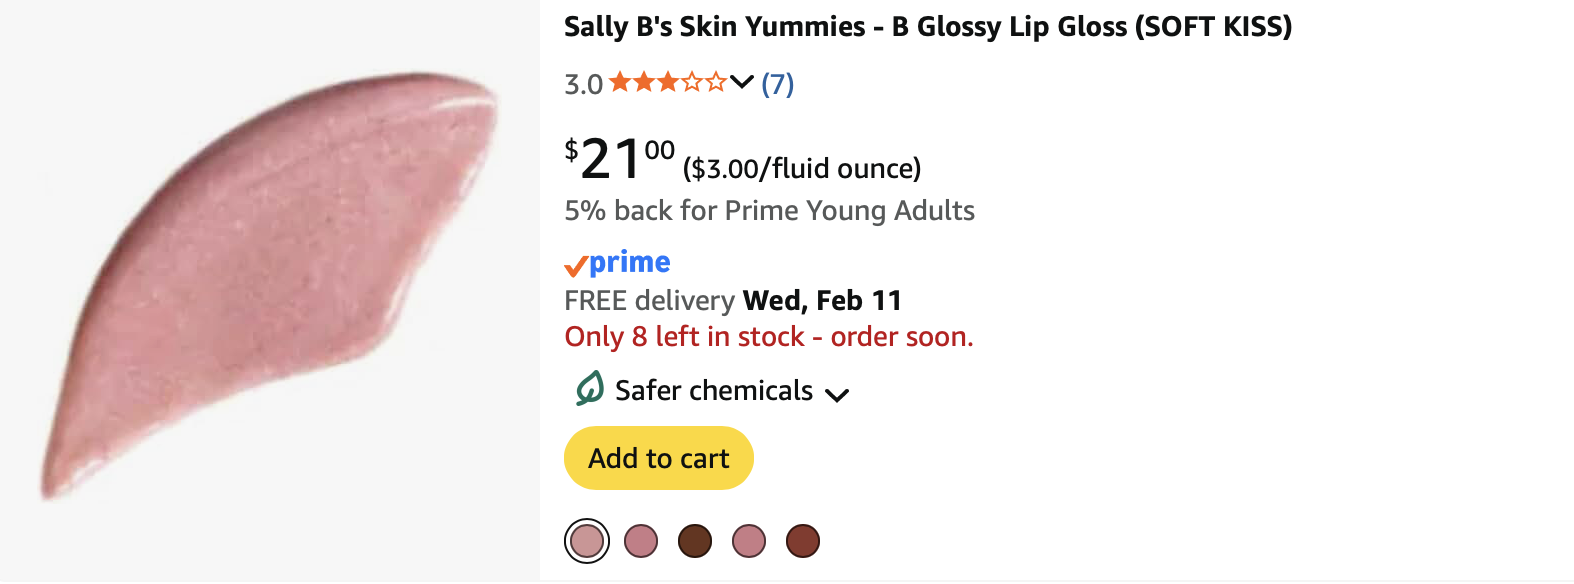

#### Figure 1. Amazon Listing

We noticed that multiple products such as this one, contained a price of $0. We were unsure as to whether this value represented missing data, promotional pricing, or products that were unavailable for purchase at the time of data collection. As a result, these entries were treated as missing values and excluded from our price-based analysis to avoid skewing the results. Above is a screenshot of a potential price of a missing product. However, we are unsure whether this cost reflected the price at the time the API was created. 

In [15]:
# Rating sanity check
df_raw["rating"].describe()

count    340.000000
mean       4.319118
std        0.675849
min        1.500000
25%        4.000000
50%        4.500000
75%        5.000000
max        5.000000
Name: rating, dtype: float64

The rating variable appears to be well-behaved and internally consistent. Ratings are bounded between 1.5 and 5, which aligns with the expected 0–5 rating scale. The distribution is skewed toward higher values, with a median rating of 4.5 and an upper quartile at 5.0, suggesting generally positive consumer feedback among rated products. No implausible rating values are observed.

In [16]:
# Create analysis subset for price vs rating
analysis_cols = [
    "brand",
    "name",
    "product_type",
    "price_num",
    "rating"
] 

In [17]:
df_analysis = (
    df_raw[analysis_cols].dropna(subset=["price_num", "rating"]).loc[df_raw["price_num"] > 0] 
) #drop row if null. Select rows that Price_num> 0

df_analysis.shape

(340, 5)

In [18]:
df_analysis.describe()

,price_num,rating
count,340.000000,340.000000
mean,14.235618,4.319118
std,8.138598,0.675849
min,1.990000,1.500000
25%,9.715000,4.000000
50%,11.990000,4.500000
75%,17.290000,5.000000
max,60.000000,5.000000


Within the analysis subset, the maximum observed price is $60, which is not particularly high relative to the broader makeup market. This likely reflects the fact that our analysis is restricted to products with available ratings. More expensive products may receive fewer consumer reviews and therefore lack ratings, causing them to be excluded from the subset. As a result, the observed price range may underrepresent higher-end products.

In [19]:
# Price range by product type
price_by_type = (
    df_analysis.groupby("product_type")["price_num"].agg( #agg: to do summary statistics on groupby
        count="count",
        min_price="min",
        q25=lambda x: x.quantile(0.25), #lambda is an anonymous function, for quickness
        median_price="median",
        q75=lambda x: x.quantile(0.75),
        max_price="max",
        mean_price="mean"
    )
    .sort_values("median_price", ascending=False) #sorted values
)

price_by_type

,count,min_price,q25,median_price,q75,max_price,mean_price
product_type,,,,,,,
bronzer,24,4.99,11.6150,19.99,25.2500,60.00,21.151667
foundation,54,4.99,11.9925,17.14,19.9900,44.00,17.628333
blush,36,6.99,9.9900,14.24,15.9900,32.00,15.139444
eyeliner,53,1.99,8.9900,10.99,14.7900,30.00,11.891509
eyeshadow,40,1.99,7.7475,10.99,17.9900,56.49,14.631250
lipstick,40,1.99,9.7400,10.99,13.9675,34.00,12.473500
mascara,49,3.49,9.9900,10.99,15.7900,33.00,12.822041
nail_polish,33,1.99,8.0000,10.00,14.9900,22.49,11.563636
lip_liner,11,3.99,4.9900,9.99,11.7400,20.49,10.109091


In [20]:
#2nd speaker: Imported plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt

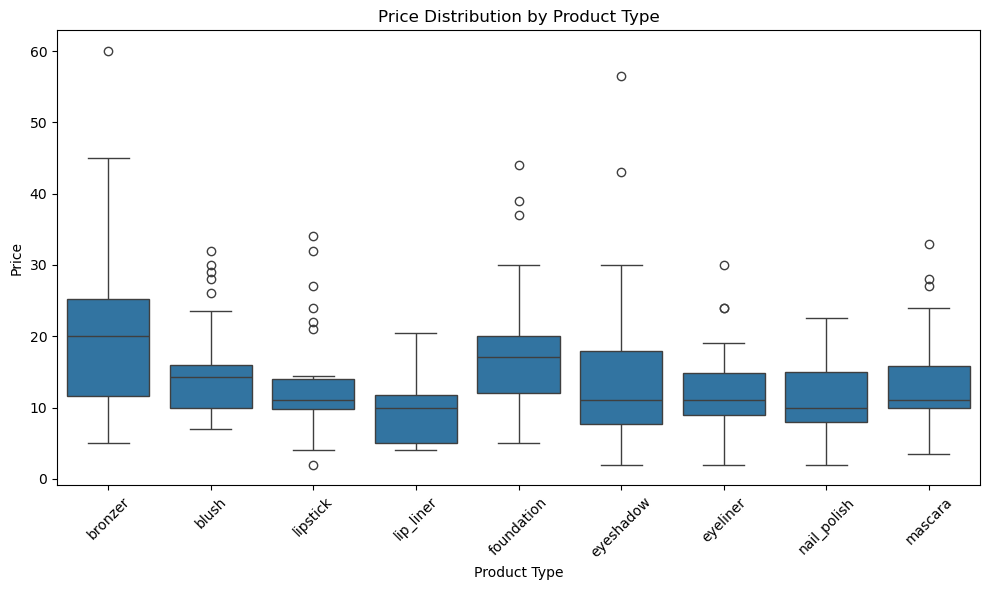

In [21]:
plt.figure(figsize=(10, 6)) #created a boxplot

sns.boxplot(
    data=df_analysis, #based on our dataframe's qualities
    x="product_type",
    y="price_num"
)

plt.xlabel("Product Type") #labeled accordingly
plt.ylabel("Price")
plt.title("Price Distribution by Product Type")
plt.xticks(rotation=45) #no overlap on labels/rotation
plt.tight_layout()
plt.show()

In [22]:
# Correlation matrix
corr = df_analysis[["price_num", "rating"]].corr() #correlation for price and rating
corr

,price_num,rating
price_num,1.000000,0.018888
rating,0.018888,1.000000


We didn't see a meaningful correlation between rating and prices, overall, so we determined it would be important to do it by product type.

In [23]:
# Correlation between price and rating: by product type
corr_by_type = (
    df_analysis.groupby("product_type")
        .apply(lambda x: x["price_num"].corr(x["rating"])).reset_index().rename(columns={0: "price_rating_corr"}) #function
        .sort_values("price_rating_corr", ascending=False)
)

corr_by_type

,product_type,price_rating_corr
8,nail_polish,0.146070
1,bronzer,0.143658
5,lip_liner,0.110326
4,foundation,0.095679
0,blush,0.075796
6,lipstick,0.036707
2,eyeliner,-0.090764
7,mascara,-0.097446
3,eyeshadow,-0.294135


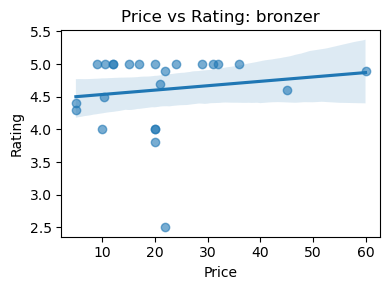

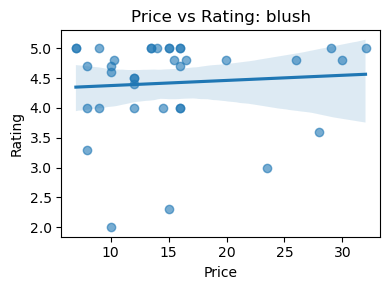

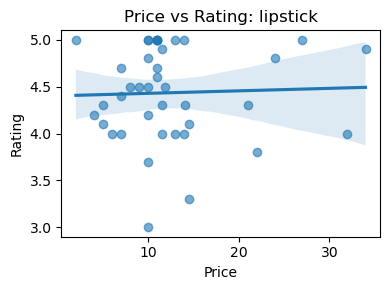

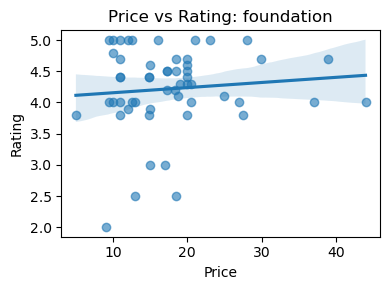

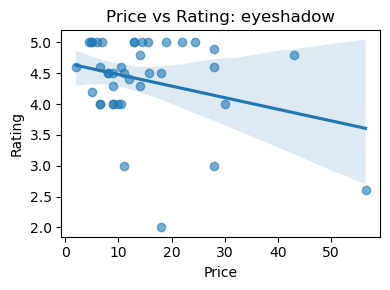

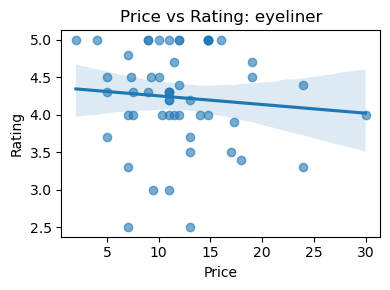

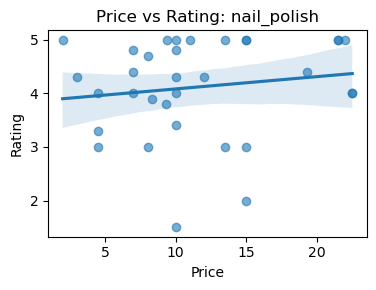

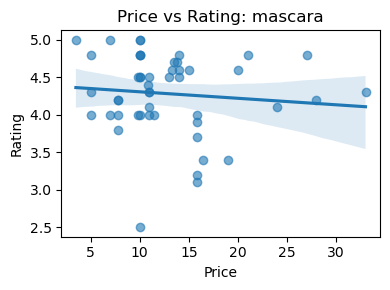

In [24]:
#Now, created these regression plots, we analyze price vs rating by product type
product_types = df_analysis["product_type"].unique() #returns all distinct values in column/for duplicates

for pt in product_types: #loop to check for all product types
    subset = df_analysis[df_analysis["product_type"] == pt] #subset for each product
    
    if len(subset) < 20: #if product-type has less than 20 items:
        continue  # skip very small groups
    
    plt.figure(figsize=(4, 3))
    sns.regplot(
        data=subset,
        x="price_num",
        y="rating",
        scatter_kws={"alpha": 0.6} #transparency feature
    )
    
    plt.title(f"Price vs Rating: {pt}")
    plt.xlabel("Price")
    plt.ylabel("Rating")
    plt.tight_layout()
    plt.show()

## Summary I

Table X reports the correlation between price and consumer rating calculated separately for each product type. Across all categories, the correlations are relatively small in magnitude, indicating that price is generally a weak predictor of consumer satisfaction.

Notably, the direction of the relationship varies by product type. For example, nail polish and bronzer exhibit weak positive correlations, suggesting that higher-priced products in these categories tend to receive slightly higher ratings. In contrast, categories such as mascara, eyeliner, and especially eyeshadow show negative correlations, indicating that higher prices are not associated with higher ratings and may even correspond to lower consumer evaluations.

These results highlight substantial heterogeneity across product types and suggest that the relationship between price and perceived quality is category-specific rather than universal.

In [25]:
# 3rd speaker: Now, for our Feature Engineering section
df_analysis["rating_tier"] = pd.cut(df_analysis["rating"], bins=[0, 4.0, 4.5, 5.0], labels=["Low", "Medium", "High"],include_lowest=True)
#Created rating tiers, using the binning method learned in class, associating the labels "low","medium", and "high" to them.

df_analysis[["rating", "rating_tier"]].head() #we display the first 5 items of this new column

,rating,rating_tier
472,5.0,High
475,5.0,High
477,4.0,Low
484,5.0,High
486,4.7,High


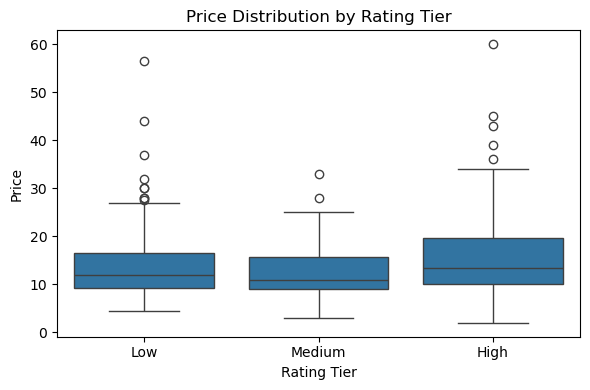

In [26]:
#We created a boxplot of price distribution by rating tier
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df_analysis, x="rating_tier", y="price_num", order=["Low", "Medium", "High"]
) #using the new rating tier feature 

plt.xlabel("Rating Tier")
plt.ylabel("Price")
plt.title("Price Distribution by Rating Tier")
plt.tight_layout()
plt.show()

The picture shows the distribution of prices across rating tiers. Products in the high-rating tier exhibit a slightly higher median price and a wider upper range compared to the low and medium tiers. However, the substantial overlap in price distributions indicates that highly rated products are not consistently more expensive. This suggests that higher consumer ratings do not require higher prices.

## Summary II

The rating tiers are defined based on the empirical distribution of ratings observed earlier. Specifically, the cutoffs at 4.0 and 4.5 correspond to the lower quartile and median of the rating distribution, respectively. This approach avoids arbitrary thresholds and reflects how ratings are actually distributed in the data.

In earlier analyses, we observed very weak correlations between price and rating when treating rating as a continuous variable. This is likely driven by the highly concentrated nature of ratings: approximately 75% of products have ratings of 4.0 or higher, leaving limited variation for correlation-based measures to detect meaningful relationships.

By transforming ratings into categorical tiers, we reduce the influence of small numerical differences and instead focus on broader distinctions in consumer satisfaction. Under this representation, differences in price distributions across rating tiers become more apparent. While the relationship remains modest, the tiered analysis reveals structural patterns that are less visible when ratings are treated as a continuous variable.

In [27]:
# Compute average rating by product type, creating a new column of average rating by product_type
type_avg_rating = (
    df_analysis.groupby("product_type")["rating"].mean().reset_index().rename(columns={"rating": "type_avg_rating"})
) #groupby product type, and get the mean of the rating columns, and rename column, after resetting index

type_avg_rating.head() #first 5 items

,product_type,type_avg_rating
0,blush,4.419444
1,bronzer,4.608333
2,eyeliner,4.230189
3,eyeshadow,4.392500
4,foundation,4.218519


In [28]:
# Merge category-level average rating
df_analysis = df_analysis.merge(type_avg_rating, on="product_type",how="left") #.merge() type_avg_rating category to dataframe

df_analysis.head() #We get first 5 items

,brand,name,product_type,price_num,rating,rating_tier,type_avg_rating
0,nyx,NYX Mosaic Powder Blush Paradise,bronzer,10.49,5.0,High,4.608333
1,annabelle,Annabelle Biggy Bronzer Haute Gold,bronzer,11.99,5.0,High,4.608333
2,physicians formula,Physicians Formula Super BB InstaReady Filter ...,bronzer,19.99,4.0,Low,4.608333
3,maybelline,Maybelline Face Studio Master Hi-Light Light B...,bronzer,14.99,5.0,High,4.608333
4,physicians formula,Physicians Formula Bronze Booster Glow-Boostin...,bronzer,20.99,4.7,High,4.608333


In [29]:
#  We, again, compute average rating for each product_type (category)
type_avg = (df_analysis.groupby("product_type")["rating"].mean().rename("type_avg_rating"))
#grouping by product type, get the average rating, and renaming the column

#  Map the category mean back to each product row with .map() method using a dictionary
df_analysis["type_avg_rating"] = df_analysis["product_type"].map(type_avg)

#  Now, we create recommended flag at the product level, using 1 for True, and 0 for False (or not recommended)
df_analysis["recommended"] = (df_analysis["rating"] > df_analysis["type_avg_rating"]).astype(int)
#if the rating is larger than the product type average rating, we recommend the product. Otherwise, we don't

In [30]:
df_analysis[
    ["brand", "name", "product_type", "rating", "rating_tier", "type_avg_rating", "recommended"]
].head(10) #take a look at selected categories for the dataframe

,brand,name,product_type,rating,rating_tier,type_avg_rating,recommended
0,nyx,NYX Mosaic Powder Blush Paradise,bronzer,5.0,High,4.608333,1
1,annabelle,Annabelle Biggy Bronzer Haute Gold,bronzer,5.0,High,4.608333,1
2,physicians formula,Physicians Formula Super BB InstaReady Filter ...,bronzer,4.0,Low,4.608333,0
3,maybelline,Maybelline Face Studio Master Hi-Light Light B...,bronzer,5.0,High,4.608333,1
4,physicians formula,Physicians Formula Bronze Booster Glow-Boostin...,bronzer,4.7,High,4.608333,1
5,NaN,Earth Lab Loose Mineral Bronzer,bronzer,5.0,High,4.608333,1
6,cargo cosmetics,Cargo Cosmetics Swimmables Water Resistant Bro...,bronzer,5.0,High,4.608333,1
7,maybelline,Maybelline Fit Me Bronzer,bronzer,4.5,Medium,4.608333,0
8,physicians formula,Physicians Formula Bronze Booster Airbrushing ...,bronzer,5.0,High,4.608333,1
9,covergirl,CoverGirl Clean Glow Bronzer,bronzer,5.0,High,4.608333,1


In [31]:
final_cols = [
    "brand",
    "name",
    "product_type",
    "price_num",
    "rating",
    "rating_tier",
    "type_avg_rating",
    "recommended"
]

for product_type, df_sub in df_analysis.groupby("product_type"):
    df_sub[final_cols].to_csv(
        f"makeup_{product_type}_final.csv",
        index=False
    ) #Here, we create separate Excel files for each product type, including the new features, for easy access to recommendations

For ease of inspection and downstream use, we split the final analysis dataset into separate tables by product type. Each table contains product-level information along with engineered features, including rating tiers and recommendation indicators, and is saved locally as an individual CSV file.

### Section Summary
To support product-level comparison and recommendation, we construct a cleaned analysis subset containing only products with valid prices and ratings. Building on this subset, we introduce two interpretable features that capture both absolute and relative product quality.

First, products are categorized into rating tiers (Low, Medium, High) based on empirically motivated cutoffs derived from the rating distribution. This transformation accounts for the highly concentrated nature of ratings, where the majority of products receive scores above 4.0, and enables clearer comparison across satisfaction levels.

Second, we compute the average rating within each product type and compare each product’s individual rating to its category average. Products with ratings exceeding their category mean are flagged as recommended. This relative measure adjusts for systematic differences across product types and highlights products that outperform their peers within the same category.

Together, these features provide a structured and interpretable framework for identifying high-performing products while acknowledging heterogeneity across categories. The resulting tables allow for category-specific inspection and serve as a foundation for downstream analysis or recommendation use cases.

### Additional Information: External Data Set

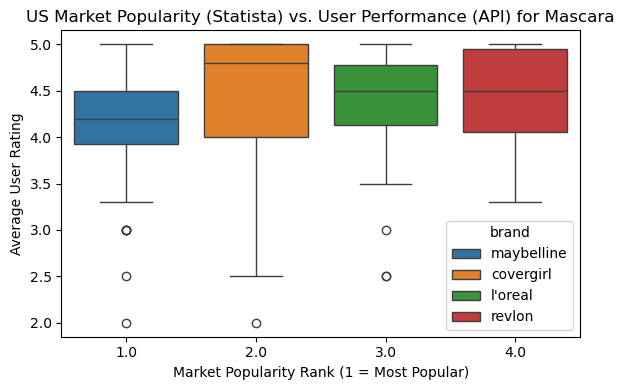

In [32]:
# Created the external dataset (as a dictionary), giving rankings to top 4 brands
#from Statista insights (U.S. population: Which brands of mascara do you use most often?)
popularity_data = {
    'maybelline': 1,
    'covergirl': 2,
    'l\'oreal': 3,
    'revlon': 4,
}
#we create a market_popularity_rank column, selecting data corresponding to top 4 brands. 
df_analysis['market_popularity_rank'] = df_analysis['brand'].str.lower().map(popularity_data)
#.map helps identify brands between api and our rankings using dictionary

# Create a 'Popularity vs. Performance' Rank
market_leaders = df_analysis[df_analysis['market_popularity_rank'].notnull()].copy() 
#create variable for plotting, making sure values are not null

#we created a boxplot showing brands by market popularity and their average user ratings 
plt.figure(figsize=(6, 4)) #specified fig size

sns.boxplot(
    data=market_leaders, x="market_popularity_rank", y="rating", hue='brand'
)

plt.title('US Market Popularity (Statista) vs. User Performance (API) for Mascara') #formatting conventions
plt.xlabel('Market Popularity Rank (1 = Most Popular)')
plt.ylabel('Average User Rating')
plt.tight_layout()

plt.show()

#### Output:
This external dataset: Statista insights "U.S. population: Which brands of mascara do you use most often?" shows us the top 4 more used mascara brands and the average user rating using our API data. The boxplot shows that higher market popularity does not correspond to higher user satisfaction. For example, Maybelline is the most popular mascara brand, yet it has the lowest median user rating. This highlights a disconnect between market dominance and user experience. So, there are likely many other factors besides popularity that contribute to higher average user ratings.

## SQL: Price, Quality, Description Premiums & Green Claims

In [33]:
# Here we are importing the necessary libraries/ packages for our analysis. 
import sqlite3
import pandas as pd
import numpy as np
import requests

In [34]:
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 1200)

# We are setting the max columns and width displayed for optimal memory usage.


### Pull data from the same API as the main notebook 

In [35]:
BASE_URL = "http://makeup-api.herokuapp.com/api/v1/products.json"
resp = requests.get(BASE_URL, timeout=30)
resp.raise_for_status()
data_json = resp.json()
df_raw = pd.DataFrame(data_json)

### Pre-process columns before loading into SQLite

In [36]:

df_raw["price"]              = pd.to_numeric(df_raw["price"], errors="coerce")
df_raw["rating"]             = pd.to_numeric(df_raw["rating"], errors="coerce")
df_raw["description_length"] = df_raw["description"].fillna("").str.len()
df_raw["word_count"]         = df_raw["description"].fillna("").str.split().str.len()
# Flatten the tag_list (Python list) into a comma-separated lowercase string
df_raw["tags"]               = df_raw["tag_list"].apply(
    lambda x: ",".join(x).lower() if isinstance(x, list) else ""
)

print(f"Records loaded: {len(df_raw)}")

Records loaded: 931


### Create in-memory SQLite database 

In [37]:

conn = sqlite3.connect(":memory:")


### TABLE 1: products  (main dataset from the API)

In [38]:
# We decided to grab the following column names for our SQL analysis
cols_for_sql = [
    "id", "brand", "name", "price", "rating",
    "product_type", "category", "description",
    "description_length", "word_count", "tags"
]
df_raw[cols_for_sql].to_sql("products", conn, index=False, if_exists="replace")

931

### TABLE 2: green_terms  (hand-coded reference / lookup table -- based on most popular tags in the space)
###   Contains marketing terms associated with "clean" or "natural" beauty

In [39]:
# We are defining a new variable to hold our data frame of the most popular terms + categories we found to 
# describe eco friendly beauty 
green_terms_df = pd.DataFrame({
    "term": [
        "natural", "organic", "clean", "vegan", "cruelty free",
        "chemical free", "eco", "mineral", "plant", "sustainable",
        "non-toxic", "gluten free"
    ],
    "category": [
        "nature-based", "certified", "clean beauty", "ethical", "ethical",
        "clean beauty", "eco-friendly", "nature-based", "nature-based",
        "eco-friendly", "clean beauty", "dietary"
    ]
})
green_terms_df.to_sql("green_terms", conn, index=False, if_exists="replace")
# We put this data frame into SQL and then check how many rows we have for products and green terms. 

for tbl in ["products", "green_terms"]:
    n = pd.read_sql(f"SELECT COUNT(*) AS n FROM {tbl}", conn).iloc[0, 0]
    print(f"  {tbl}: {n} rows")

  products: 931 rows
  green_terms: 12 rows


###  QUERY 1: Basic Dataset Overview 
##### What:  High-level summary statistics for the full products table.
##### Why:   First step before any analysis — understand scale, price/rating ranges,        and extent of missing data.
##### How:   Aggregation with COUNT, AVG, MIN, MAX; CASE WHEN to handle NULLs/zeros.

In [40]:
q1 = """
SELECT
    COUNT(*)                                                              AS total_products,
    COUNT(DISTINCT brand)                                                 AS unique_brands,
    COUNT(DISTINCT product_type)                                          AS unique_product_types,
    ROUND(AVG(CASE WHEN price > 0 THEN price END), 2)                    AS avg_price,
    ROUND(MIN(CASE WHEN price > 0 THEN price END), 2)                    AS min_valid_price,
    ROUND(MAX(price), 2)                                                  AS max_price,
    SUM(CASE WHEN price IS NULL OR price = 0 THEN 1 ELSE 0 END)          AS invalid_price_count,
    ROUND(AVG(rating), 2)                                                 AS avg_rating,
    SUM(CASE WHEN rating IS NULL THEN 1 ELSE 0 END)                       AS missing_rating_count,
    ROUND(100.0 * SUM(CASE WHEN rating IS NULL THEN 1 ELSE 0 END)
          / COUNT(*), 1)                                                  AS rating_missing_pct
FROM products;
"""
#Here, we are pulling the data from our API and making it into a more readable format. 
#For example, we go the summary statistics and renamed our columns using the AS operator.

print("=== Query 1: Basic Dataset Overview ===")
pd.read_sql(q1, conn)

# We print it to see our output


=== Query 1: Basic Dataset Overview ===


,total_products,unique_brands,unique_product_types,avg_price,min_valid_price,max_price,invalid_price_count,avg_rating,missing_rating_count,rating_missing_pct
0,931,57,10,17.26,1.99,77.0,54,4.32,591,63.5


#### Output: We can gather tha ther are 931 products, ~50 brands, 9 product types.
##### 63.5% of products are missing ratings, which is a significant limitation noted previosuly in EDA.


### QUERY 2: Missing Data Analysis by Column 
##### What:  Count and percentage of missing values for each key column.
##### Why:   Systematic data quality check. Informs which analyses are reliable.
##### How:   CASE WHEN to flag NULLs per column; UNION ALL to stack results vertically.

In [41]:
# Here we are using the SELECT operator for each of our categories from the products data frame. We are calculating
# the total missing products using the SUM operator. We then calculate a total percentage of missing data from
# each column/ category for our reference, and round that number. 

q2 = """
SELECT 'brand'        AS column_name,
    SUM(CASE WHEN brand IS NULL THEN 1 ELSE 0 END)                       AS missing_count,
    ROUND(100.0 * SUM(CASE WHEN brand IS NULL THEN 1 ELSE 0 END)
          / COUNT(*), 1)                                                  AS missing_pct
FROM products
UNION ALL
SELECT 'price',
    SUM(CASE WHEN price IS NULL OR price = 0 THEN 1 ELSE 0 END),
    ROUND(100.0 * SUM(CASE WHEN price IS NULL OR price = 0 THEN 1 ELSE 0 END)
          / COUNT(*), 1)
FROM products
UNION ALL
SELECT 'rating',
    SUM(CASE WHEN rating IS NULL THEN 1 ELSE 0 END),
    ROUND(100.0 * SUM(CASE WHEN rating IS NULL THEN 1 ELSE 0 END)
          / COUNT(*), 1)
FROM products
UNION ALL
SELECT 'description',
    SUM(CASE WHEN description IS NULL OR description = '' THEN 1 ELSE 0 END),
    ROUND(100.0 * SUM(CASE WHEN description IS NULL OR description = '' THEN 1 ELSE 0 END)
          / COUNT(*), 1)
FROM products
UNION ALL
SELECT 'product_type',
    SUM(CASE WHEN product_type IS NULL THEN 1 ELSE 0 END),
    ROUND(100.0 * SUM(CASE WHEN product_type IS NULL THEN 1 ELSE 0 END)
          / COUNT(*), 1)
FROM products
ORDER BY missing_pct DESC;
"""
# This helps us have a better idea of what data is missing so that we can address it later on. 

print("=== Query 2: Missing Data by Column ===")
pd.read_sql(q2, conn)


=== Query 2: Missing Data by Column ===


,column_name,missing_count,missing_pct
0,rating,591,63.5
1,price,54,5.8
2,description,25,2.7
3,brand,12,1.3
4,product_type,0,0.0


### Output: 
##### We can observe that rating (at 63.5%) has the most missing data. However, price itself is mostly complete (5.8% missing/zero), so price analysis is viable.


###  QUERY 3: Price Tier Distribution
##### What:  Classify products into 4 price tiers; compute product count, avg price, avg rating, and brand diversity per tier. 
##### Why:   Establishes price segmentation framework used throughout the analysis. Lets us test whether higher-tier products also get better ratings.
##### How:   CASE WHEN creates tier labels; GROUP BY aggregates metrics per tier.

In [42]:
#Here, we engineer and SELECT the conditional tiers for prices, stored in price_tier,
#going from Budget to Luxury product. Then, we also select the avg, min, max price
#as well as the avg rating and the number of distinct brands, using the products data table
#Filtering using WHERE for price larger than 0. Grouping by and ordering by price_tier.
q3 = """
SELECT
    CASE
        WHEN price < 10  THEN '1_Budget      (<$10)'
        WHEN price < 20  THEN '2_Mid-range   ($10–19)'
        WHEN price < 35  THEN '3_Premium     ($20–34)'
        ELSE                  '4_Luxury      ($35+)'
    END                                AS price_tier,
    COUNT(*)                           AS product_count,
    ROUND(AVG(price), 2)               AS avg_price,
    ROUND(MIN(price), 2)               AS min_price,
    ROUND(MAX(price), 2)               AS max_price,
    ROUND(AVG(rating), 2)              AS avg_rating,
    COUNT(DISTINCT brand)              AS distinct_brands
FROM products
WHERE price > 0
GROUP BY price_tier
ORDER BY price_tier;
"""

print("=== Query 3: Price Tier Distribution (GROUP BY) ===")
pd.read_sql(q3, conn)



=== Query 3: Price Tier Distribution (GROUP BY) ===


,price_tier,product_count,avg_price,min_price,max_price,avg_rating,distinct_brands
0,1_Budget (<$10),259,7.33,1.99,9.99,4.31,23
1,2_Mid-range ($10–19),321,14.18,10.00,19.99,4.29,28
2,3_Premium ($20–34),232,25.33,20.00,34.50,4.43,22
3,4_Luxury ($35+),65,43.29,35.00,77.00,4.33,10


### Output: 
It is observable that most products fall in the Mid-range tier ($10–19), with a count of 321. Also, Avg ratings are similar across tiers (~4.3), supporting a **weak price-quality** link.


### QUERY 4: Green Tag Distribution by Product Type 
##### What:  Count how many products per product_type carry at least one green/ethical
##### self-declared tag (vegan, organic, natural, chemical free).
##### Why:   Baseline for the green hypothesis — which categories skew "green"?
##### How:   CASE WHEN + LIKE to detect green tags; GROUP BY product_type.

In [43]:
# We SELECT product type and count all of its chosen categories (for example, for the green tags, when a description contains
# any of the green tokens ("%vegan%","%organic%", etc.) we can count them as 1 (TRUE) or 0 (FALSE) if not present and put them
# in a column using AS from our products table, taking out NULLS with WHERE __ IS NOT NULL. Grouping by product_type
# And Ordering them as Descending based on percentage green

q4 = """
SELECT
    product_type,
    COUNT(*)                                                                  AS total_products,
    SUM(CASE WHEN tags LIKE '%vegan%'        THEN 1 ELSE 0 END)              AS vegan_count,
    SUM(CASE WHEN tags LIKE '%organic%'      THEN 1 ELSE 0 END)              AS organic_count,
    SUM(CASE WHEN tags LIKE '%cruelty%'      THEN 1 ELSE 0 END)              AS cruelty_free_count,
    SUM(CASE WHEN tags LIKE '%natural%'      THEN 1 ELSE 0 END)              AS natural_count,
    SUM(CASE WHEN tags LIKE '%vegan%'
              OR tags LIKE '%organic%'
              OR tags LIKE '%natural%'
              OR tags LIKE '%chemical free%' THEN 1 ELSE 0 END)              AS any_green_tag,
    ROUND(
        100.0 * SUM(CASE WHEN tags LIKE '%vegan%'
                          OR tags LIKE '%organic%'
                          OR tags LIKE '%natural%'
                          OR tags LIKE '%chemical free%' THEN 1 ELSE 0 END)
        / COUNT(*), 1)                                                        AS pct_green
FROM products
WHERE product_type IS NOT NULL
GROUP BY product_type
ORDER BY pct_green DESC;
"""

print("=== Query 4: Green Tag Distribution by Product Type (GROUP BY) ===")
pd.read_sql(q4, conn)



=== Query 4: Green Tag Distribution by Product Type (GROUP BY) ===


,product_type,total_products,vegan_count,organic_count,cruelty_free_count,natural_count,any_green_tag,pct_green
0,nail_polish,60,8,0,0,14,17,28.3
1,eyeshadow,86,13,7,0,9,21,24.4
2,bronzer,69,7,1,0,9,14,20.3
3,mascara,92,6,2,0,13,17,18.5
4,blush,78,5,1,0,8,11,14.1
5,lip_liner,29,3,0,1,2,4,13.8
6,foundation,166,8,0,3,10,16,9.6
7,eyeliner,148,9,1,0,10,14,9.5
8,lipstick,154,8,2,2,7,14,9.1
9,eyebrow,49,0,0,0,0,0,0.0


## Output:
From this analysis, by product type, nail polish (28.3%), eye shadow (24.4%), bronzer (20.3%), and mascara (18.5%) tend to have the highest % of green tags.

###  QUERY 5: Match Products to Green Terms Reference Table 
##### What:  Find products whose NAME or TAGS contain any term from the green_terms
#####        lookup table; summarize count, avg price, and avg rating per term.
##### Why:   More systematic than Query 4 — captures green language even when not
#####        explicitly tagged. Tests whether certain green keywords co-occur with
#####        price premiums.
##### How:   JOIN on LIKE condition between products and green_terms reference table.


In [116]:
# This is our first join (Join #1). We SELECT and rename with AS our green-terms categories, product type, product id DISTINC COUNT
# Then the rounded (two decimals) avergae price of products and average rating.
# We join our green_terms categories with our products data table based on lower-case standardized tokens from our green categories
# based on product name and product tags. Then, we filter by product prices being larger than 0 (not free) 
#and group by green category, green term, and product type to then order by the products matched to green term category (Descending)
#Feature Engineered matched_prodcts, avg_price, and avg_rating
q5 = """
SELECT
    gt.category                        AS green_category,
    gt.term                            AS matched_term,
    p.product_type,
    COUNT(DISTINCT p.id)               AS matched_products,
    ROUND(AVG(p.price), 2)             AS avg_price,
    ROUND(AVG(p.rating), 2)            AS avg_rating
FROM products p
JOIN green_terms gt
    ON LOWER(p.name)  LIKE '%' || gt.term || '%'
    OR LOWER(p.tags)  LIKE '%' || gt.term || '%'
WHERE p.price > 0
GROUP BY gt.category, gt.term, p.product_type
ORDER BY matched_products DESC, gt.category;
"""

print("=== Query 5: Products Matched to Green Terms (JOIN #1) ===")
df5 = pd.read_sql(q5, conn)
df5
#Frequency Graph


=== Query 5: Products Matched to Green Terms (JOIN #1) ===


,green_category,matched_term,product_type,matched_products,avg_price,avg_rating
0,dietary,gluten free,eyeliner,17,15.53,4.49
1,nature-based,natural,mascara,14,19.17,3.96
2,nature-based,natural,nail_polish,14,15.06,4.09
3,dietary,gluten free,blush,12,19.95,4.46
4,dietary,gluten free,foundation,12,19.67,4.19
5,ethical,vegan,eyeshadow,12,15.28,4.51
6,nature-based,mineral,foundation,12,20.37,4.35
7,nature-based,natural,foundation,12,26.20,4.08
8,dietary,gluten free,mascara,10,16.99,3.98
9,nature-based,natural,eyeliner,10,17.02,3.91


### Output: 
Here, 'gluten free', 'vegan', and 'natural' are the most common green terms across all types.
On the other hand, 'organic' and 'cruelty-free' appear less frequently — and they may represent a premium niche.

#### The following graphs allows us to visualize this green-term frequency:

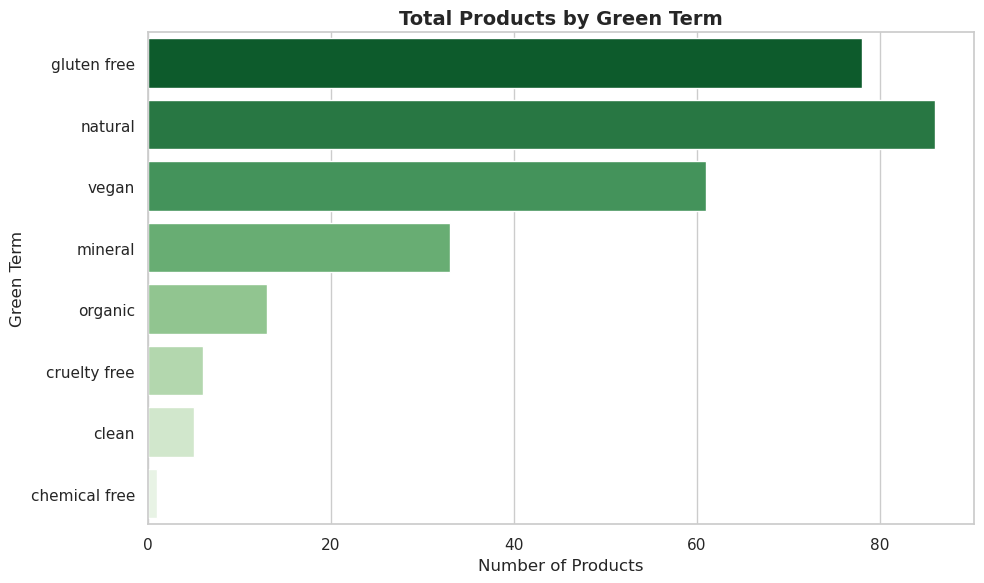

In [120]:
# Set a clean, professional style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# A bar chart aggregating the total matched products per Green Category
# Seaborn's estimator=sum will automatically add up the counts for each category
sns.barplot(
    data=df5, 
    x="matched_products", 
    y="matched_term", 
    estimator=sum, 
    errorbar=None, 
    hue="matched_term",
    legend = False,
    palette="Greens_r" # A nice thematic green color palette
)

plt.title("Total Products by Green Term", fontsize=14, weight="bold")
plt.xlabel("Number of Products", fontsize=12)
plt.ylabel("Green Term", fontsize=12)

plt.tight_layout()
plt.show()

###  QUERY 6: Green-Labeled vs Non-Green Price & Rating Comparison 
##### What:  For each product_type, compare avg price and avg rating between
#####        green-labeled and non-green products.
##### Why:   Core hypothesis test — do green marketing claims correlate with a price
#####        premium? And does that premium come with better or worse ratings?
##### How:   CTE (style 1 subquery) flags each product as green/non-green using EXISTS;
#####        outer query groups and aggregates. The CTE result is then JOINed implicitly
#####        via GROUP BY (JOIN #2 is the brand_stats join in Q13).

In [121]:
# We use WITH to define a temporary table named green_flag, for future use.
#Then, we SELECT product id, type, price, and rating, as well as the conditional subquery
#FROM green_terms, filtering using WHERE to convert product name and tags to lower case and
#then check if any "green term" exists anywhere inside those strings. Then, the product is
#labeled "Green-label" or "Non-green".
#Finally, the source is FROM products and we filter for free or erroneous prices.
#Then, the second part of the query uses this green_flag table, counting the total number
#of products that fall into each category. Then, we round AVG price and AVG rating for standard.
# We run these on green_flag temporary table. To, then, Group by product type and green label
#and order by product type and green_label

q6 = """
WITH green_flag AS (
    SELECT
        p.id,
        p.product_type,
        p.price,
        p.rating,
        CASE
            WHEN EXISTS (
                SELECT 1
                FROM green_terms gt
                WHERE LOWER(p.name) LIKE '%' || gt.term || '%'
                   OR LOWER(p.tags) LIKE '%' || gt.term || '%'
            ) THEN 'Green-Labeled'
            ELSE 'Non-Green'
        END AS green_label
    FROM products p
    WHERE p.price > 0
)
SELECT
    product_type,
    green_label,
    COUNT(*)               AS product_count,
    ROUND(AVG(price), 2)   AS avg_price,
    ROUND(AVG(rating), 2)  AS avg_rating
FROM green_flag
GROUP BY product_type, green_label
ORDER BY product_type, green_label;
"""

print("=== Query 6: Green vs Non-Green Comparison (CTE subquery) ===")
df6 = pd.read_sql(q6, conn)
df6

=== Query 6: Green vs Non-Green Comparison (CTE subquery) ===


,product_type,green_label,product_count,avg_price,avg_rating
0,blush,Green-Labeled,20,16.99,4.27
1,blush,Non-Green,52,18.54,4.55
2,bronzer,Green-Labeled,19,22.62,4.46
3,bronzer,Non-Green,48,23.73,4.90
4,eyebrow,Green-Labeled,1,44.00,NaN
5,eyebrow,Non-Green,46,20.92,NaN
6,eyeliner,Green-Labeled,23,14.26,4.28
7,eyeliner,Non-Green,120,12.73,4.21
8,eyeshadow,Green-Labeled,18,16.56,4.59
9,eyeshadow,Non-Green,54,22.45,4.26


## Output: 
Green-labeled products tend to have slightly higher avg prices in most
categories. However, there are numerous products for which green-labeled products are slightly cheaper on average. So, these rating differences are small — thus, green claims don't clearly translate to higher prices or better consumer satisfaction (as seen on the ratings).

# GRAPH comparing avg prices for each product!!

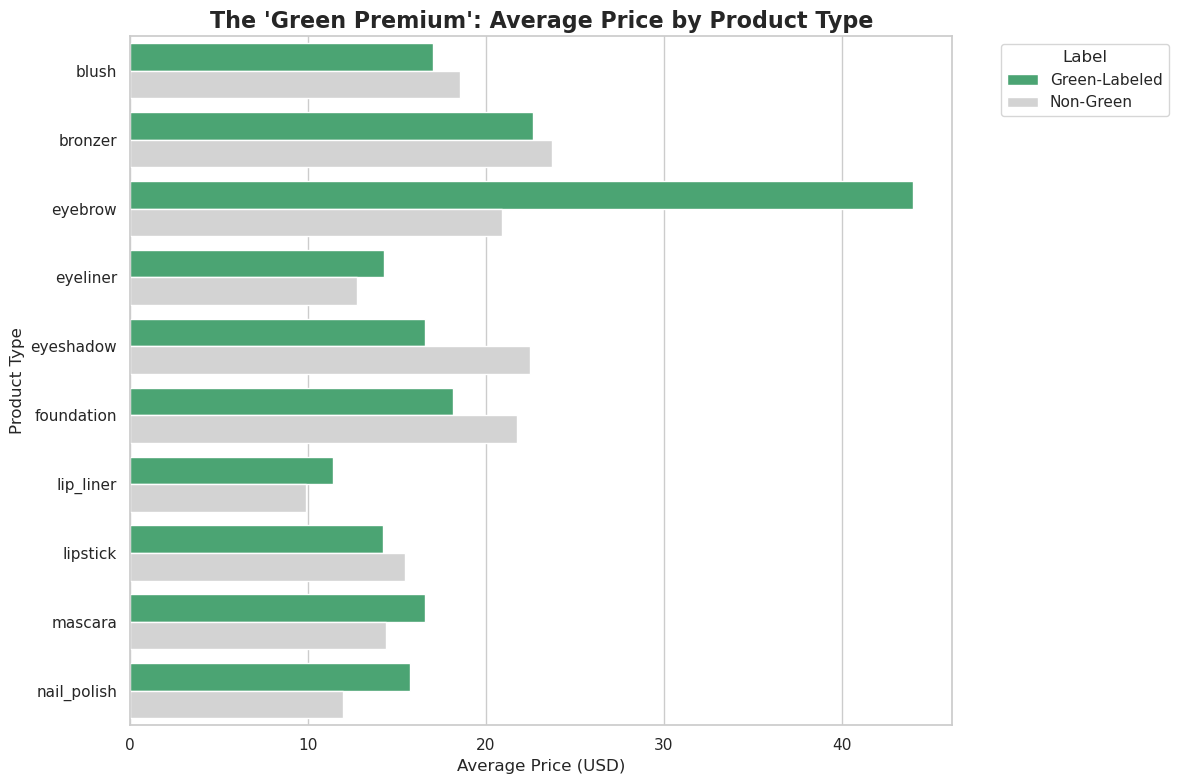

In [122]:
plt.figure(figsize=(12, 8))

# A grouped horizontal bar chart
# We use a custom dictionary for the palette to ensure 'Green-Labeled' is actually green
sns.barplot(
    data=df6, 
    x="avg_price", 
    y="product_type", 
    hue="green_label", 
    palette={"Green-Labeled": "mediumseagreen", "Non-Green": "lightgray"}
)

plt.title("The 'Green Premium': Average Price by Product Type", fontsize=16, weight="bold")
plt.xlabel("Average Price (USD)", fontsize=12)
plt.ylabel("Product Type", fontsize=12)

# Move the legend outside the chart to keep it clean
plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### QUERY 7: Brand Performance Summary 
##### What:  For brands with ≥5 products, aggregate price range, avg rating, number of
#####        categories covered, and count of green-tagged products.
##### Why:   Understand brand-level positioning. Brands with broad category coverage
#####        and high ratings may be better bets for value-conscious consumers.
##### How:   GROUP BY brand; HAVING filters for statistical meaningfulness (≥5 products).


In [124]:
# Here we make the variabkle q7 and assign the following queries:
q7 = """
SELECT
    brand,
    COUNT(*)                                                              AS total_products,
    COUNT(DISTINCT product_type)                                          AS categories_covered,
    ROUND(AVG(price), 2)                                                  AS avg_price,
    ROUND(MIN(price), 2)                                                  AS min_price,
    ROUND(MAX(price), 2)                                                  AS max_price,
    ROUND(AVG(rating), 2)                                                 AS avg_rating,
    SUM(CASE WHEN rating IS NOT NULL  THEN 1 ELSE 0 END)                  AS rated_products,
    SUM(CASE WHEN tags LIKE '%vegan%'
              OR tags LIKE '%organic%'
              OR tags LIKE '%natural%' THEN 1 ELSE 0 END)                 AS green_products
FROM products
WHERE price > 0
  AND brand IS NOT NULL
GROUP BY brand
HAVING COUNT(*) >= 5
ORDER BY avg_rating DESC, total_products DESC
LIMIT 20;
"""
# We first start with the SELECT operator where we grab the brand and create the following columns:
# total_ products ---> We grab the total amount using the COUNT operator
# categories_covered ---> We grab the total count of distinct product types witht the DISTINCT operator
# avg_price & avg_rating ---> We are rounding the average price & rating to two decimal points with the ROUND & AVG operators
# min_price & max_price ---> We are rounding the max price using the MAX operator

# In order to count the number of not-null items, we have to use the SUM operator and assign the values 1 if not null, 0 if otherwise.
# For our pattern matching/ tokenization we use the same structure with the SUM operator, grouping the use of the words "vegan", "organic", and "natural" as 
# a new column called green_products

# Lastly, from the products table, where price is greater than zero and the brand name is present we are grouping by the following atributes:
#  -- brand count have greater than or equal to 5
#  -- ordering from the highest average rating, and the lowest total product counts
#  -- limiting the coutnt to 20

print("=== Query 7: Brand Performance Summary (GROUP BY + HAVING) ===")
df7 = pd.read_sql(q7, conn) 

df7 
# Here we read and print our sql queries to derive the following table: 

=== Query 7: Brand Performance Summary (GROUP BY + HAVING) ===


,brand,total_products,categories_covered,avg_price,min_price,max_price,avg_rating,rated_products,green_products
0,annabelle,11,5,9.81,6.99,11.99,4.97,6,0
1,cargo cosmetics,20,7,29.25,19.00,42.00,4.85,11,0
2,dr. hauschka,12,6,33.92,22.00,45.00,4.67,10,7
3,wet n wild,12,5,4.31,1.99,6.99,4.67,9,0
4,milani,13,7,9.07,3.99,12.99,4.48,10,1
5,pacifica,13,8,25.46,14.00,60.00,4.47,12,13
6,revlon,29,7,13.49,6.99,19.99,4.46,23,0
7,pure anada,16,8,14.25,8.00,25.99,4.46,15,16
8,covergirl,54,9,9.68,4.49,15.99,4.43,33,0
9,e.l.f.,27,8,6.77,3.99,13.99,4.38,22,21


## Output: 
Top-rated brands tend to be mid-size (5–20 products). Brands with more
green products don't consistently have higher ratings, thus green marketing does not appear to be a marker of luxury or increased quality.

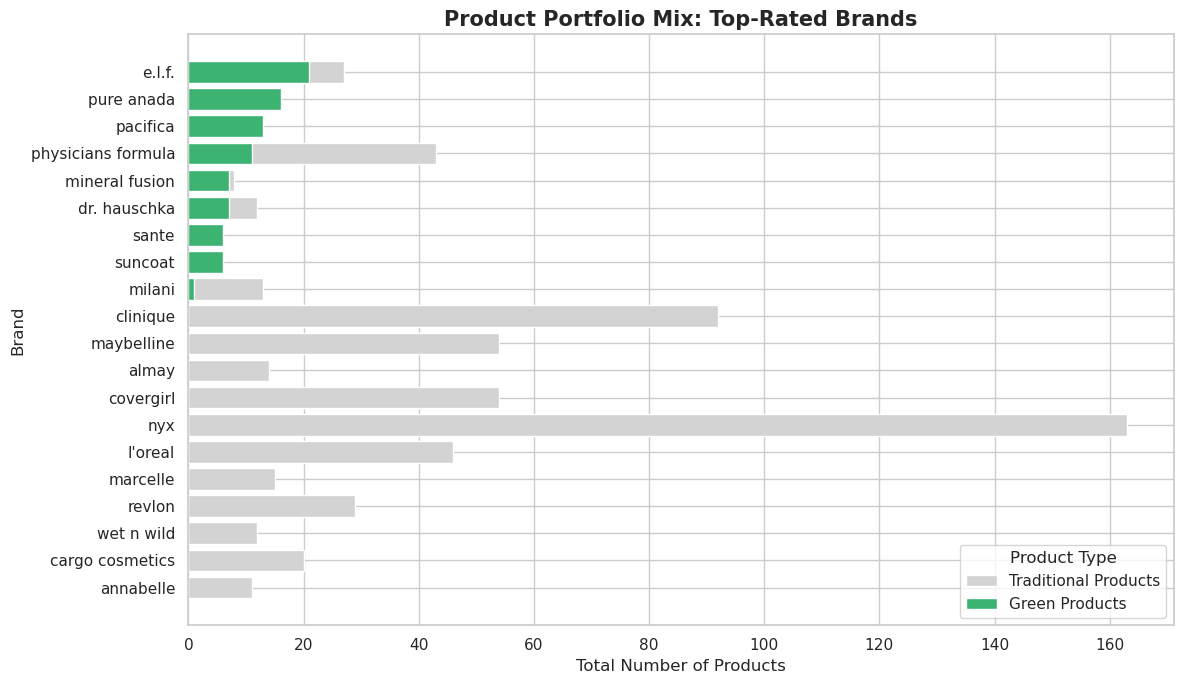

In [125]:
plt.figure(figsize=(12, 7))

# Calculate the non-green products to make the stacking math work
df7["non_green"] = df7["total_products"] - df7["green_products"]

# Sort by the sheer volume of green products for visual impact
df7_green_sort = df7.sort_values("green_products", ascending=True)

# Plot the Non-Green base first (in light gray)
plt.barh(df7_green_sort["brand"], df7_green_sort["total_products"], color="lightgray", label="Traditional Products")

# Plot the Green products on top (in green)
plt.barh(df7_green_sort["brand"], df7_green_sort["green_products"], color="mediumseagreen", label="Green Products")

plt.title("Product Portfolio Mix: Top-Rated Brands", fontsize=15, weight="bold")
plt.xlabel("Total Number of Products", fontsize=12)
plt.ylabel("Brand", fontsize=12)
plt.legend(title="Product Type", loc="lower right")

plt.tight_layout()
plt.show()

### QUERY 8: Price Rank within Product Type 
##### What:  Rank each product by price within its product_type, and show how far
#####        each product's price deviates from its category average.
##### Why:   Lets consumers see where a specific product sits price-wise among peers —
#####        more informative than raw price alone.
##### How:   RANK() OVER (PARTITION BY product_type ORDER BY price DESC) assigns rank;
#####        AVG() OVER (PARTITION BY product_type) computes the in-category mean.
#####       Both are window functions — no GROUP BY, no row collapsing.


In [123]:
# Here we assign the following query to the variable "q8"
q8 = """
SELECT
    brand,
    name,
    product_type,
    price,
    rating,
    RANK()  OVER (PARTITION BY product_type ORDER BY price DESC)          AS price_rank,
    COUNT(*) OVER (PARTITION BY product_type)                              AS products_in_type,
    ROUND(AVG(price) OVER (PARTITION BY product_type), 2)                 AS type_avg_price,
    ROUND(price - AVG(price) OVER (PARTITION BY product_type), 2)         AS price_vs_type_avg
FROM products
WHERE price > 0
ORDER BY product_type, price_rank;
"""
# We are selecting the brand, name, product, price, and rating. Then, using the window functions RANK() and PARTITION we are ranking based on
# how far the product price deviates from the average category product price. We assign this value to the column "price_rank". We continue to 
# partition by (do calculations across rows, keeping the rows) to list our average prices based on product types and get the difference 
# between the price of the product and the average price for the product type. 

# Lastly, we are specifiying that we are selecting this from the products table, where price is greater than 0 dollars, and ordering by product 
# type and the price rank


print("=== Query 8: Price Rank within Product Type (Window Function #1) ===")
pd.read_sql(q8, conn) 


=== Query 8: Price Rank within Product Type (Window Function #1) ===


,brand,name,product_type,price,rating,price_rank,products_in_type,type_avg_price,price_vs_type_avg
0,stila,Stila Convertible Colour Palette Sinrise Splendor,blush,51.00,NaN,1,72,18.11,32.89
1,stila,Stila Convertible Colour Palette Sunset Serenade,blush,51.00,NaN,1,72,18.11,32.89
2,smashbox,L.A. Lights Palette,blush,35.00,NaN,3,72,18.11,16.89
3,clinique,Sculptionary&trade; Cheek Contouring Palette,blush,34.00,NaN,4,72,18.11,15.89
4,dior,Diorblush Sculpt,blush,32.50,NaN,5,72,18.11,14.39
...,...,...,...,...,...,...,...,...,...
872,maybelline,Maybelline Color Show Nail Lacquer Jewels,nail_polish,4.49,3.0,55,59,13.12,-8.63
873,maybelline,Maybelline Color Show Nail Lacquer Veils,nail_polish,4.49,4.0,55,59,13.12,-8.63
874,maybelline,Maybelline Color Show Nail Lacquer,nail_polish,4.49,3.3,55,59,13.12,-8.63
875,sinful colours,Sinful Colours Nail Polish,nail_polish,2.99,4.3,58,59,13.12,-10.13


## Output: 
The output reveals which brands dominate the high-price end of each category.
price_vs_type_avg is an engineered score that shows how far above/below its product type average price a product sits.

This is a good table for consumer reference, especially if they are budget-concious and want to make sure they are paying near or below the average market price for a certain product.

### QUERY 9: Rating Percentile within Product Type 
##### What:  Determine and compare individual rating to category average.
##### Why:   Identifies top performers relative to their category peers — useful for
#####        building a "recommended" flag (which we also did in Python EDA).
##### How:   PERCENT_RANK() OVER (PARTITION BY product_type ORDER BY rating):
#####        returns 0 for the lowest-rated, 1.0 for the highest-rated in each group.

In [71]:
# Here, we SELECT brand, name, product type, price, rating, as well as the percentage rank ordered by rating by product type. Also, the average rating for each
# make up type and the rating vs type average difference by product type to see how different the product is from its type's average rating.
# We filter by non-null ratings using WHERE and by price being larger than 0.
#Then, we order by product type and rating percentage rank, in descending order.

q9 = """
SELECT
    brand,
    name,
    product_type,
    price,
    rating,
    ROUND(PERCENT_RANK() OVER (PARTITION BY product_type ORDER BY rating), 2)  AS rating_pct_rank,
    ROUND(AVG(rating)    OVER (PARTITION BY product_type), 2)                  AS type_avg_rating,
    ROUND(rating - AVG(rating) OVER (PARTITION BY product_type), 2)            AS rating_vs_type_avg
FROM products
WHERE rating IS NOT NULL
  AND price  > 0
ORDER BY product_type, rating_pct_rank DESC;
"""

print("=== Query 9: Rating Percentile within Product Type (Window Function #2) ===")
pd.read_sql(q9, conn)


=== Query 9: Rating Percentile within Product Type (Window Function #2) ===


,brand,name,product_type,price,rating,rating_pct_rank,type_avg_rating,rating_vs_type_avg
0,NaN,Fake Bake Blush Legal Sunburn,blush,15.99,5.0,0.69,4.42,0.58
1,covergirl,CoverGirl truBLEND Blush in Medium Rose,blush,13.99,5.0,0.69,4.42,0.58
2,cargo cosmetics,Cargo Cosmetics Swimmables Water Resistant Blush,blush,29.00,5.0,0.69,4.42,0.58
3,mineral fusion,Mineral Fusion Blush,blush,32.00,5.0,0.69,4.42,0.58
4,covergirl,CoverGirl Clean Glow Blush,blush,8.99,5.0,0.69,4.42,0.58
...,...,...,...,...,...,...,...,...
335,orly,Orly EPIX Flexible Color,nail_polish,13.49,3.0,0.06,4.12,-1.12
336,orly,Orly Nail Lacquer,nail_polish,8.00,3.0,0.06,4.12,-1.12
337,maybelline,Maybelline Color Show Nail Lacquer Jewels,nail_polish,4.49,3.0,0.06,4.12,-1.12
338,moov,Moov Cosmetics Caribbean Wedding Collection,nail_polish,14.99,2.0,0.03,4.12,-2.12


## Output: 
Here, products with rating_pct_rank = 1.0 are the top-rated in their category.
Combining price_rank (from Quqry 8) with rating_pct_rank gives us a **value-for-money signal.**

### QUERY 10: Products Priced Above Their Category Average 
##### What:  Select only products whose price exceeds the average for their product_type,
#####        and show how large the premium is.
##### Why:   Isolates "premium" products within each category for targeted analysis —
#####        useful for testing if premium positioning correlates with better ratings.
##### How:   Correlated subquery in WHERE clause: for each row p, the inner SELECT
#####        re-computes AVG(price) filtered to p's product_type. This is style 1
#####        subquery (inline, correlated).

In [49]:
# Here, we SELECT product brand, name, product_type, product_price, and product_rating as well as the rounded subquery of average of p2
# p2 is the new table for product type form the product table, filtered by price larger than 0.
#using this p2, we also selected the average of p2 price for price >0 and the rounded difference of product price - average of p2 price, renamed AS
# category_avg_price and price_premium, respectively.
#Then, we filter using WHERe for product price being larger than p3 price average (a subquery where p3.prudct type is p.product type filtered to only include positive prices
#also filtering, finally, for product price larger than 0. ORDERED BY product-type and price_premium, descending.

q10 = """
SELECT
    p.brand,
    p.name,
    p.product_type,
    p.price,
    p.rating,
    ROUND(
        (SELECT AVG(p2.price)
         FROM products p2
         WHERE p2.product_type = p.product_type
           AND p2.price > 0), 2)                                           AS category_avg_price,
    ROUND(
        p.price - (SELECT AVG(p2.price)
                   FROM products p2
                   WHERE p2.product_type = p.product_type
                     AND p2.price > 0), 2)                                 AS price_premium
FROM products p
WHERE p.price > (
    SELECT AVG(p3.price)
    FROM products p3
    WHERE p3.product_type = p.product_type
      AND p3.price > 0
)
AND p.price > 0
ORDER BY p.product_type, price_premium DESC;
"""

print("=== Query 10: Products Above Category Average Price (Correlated Subquery) ===")
pd.read_sql(q10, conn)



=== Query 10: Products Above Category Average Price (Correlated Subquery) ===


,brand,name,product_type,price,rating,category_avg_price,price_premium
0,stila,Stila Convertible Colour Palette Sinrise Splendor,blush,51.00,NaN,18.11,32.89
1,stila,Stila Convertible Colour Palette Sunset Serenade,blush,51.00,NaN,18.11,32.89
2,smashbox,L.A. Lights Palette,blush,35.00,NaN,18.11,16.89
3,clinique,Sculptionary&trade; Cheek Contouring Palette,blush,34.00,NaN,18.11,15.89
4,dior,Diorblush Sculpt,blush,32.50,NaN,18.11,14.39
...,...,...,...,...,...,...,...
363,moov,Moov Cosmetics St. Tropez Collection,nail_polish,14.99,NaN,13.12,1.87
364,moov,Moov Cosmetics Caribbean Wedding Collection,nail_polish,14.99,2.0,13.12,1.87
365,moov,Moov Cosmetics Home Grown Canuck Collection,nail_polish,14.99,3.0,13.12,1.87
366,orly,Orly EPIX Flexible Sealcoat,nail_polish,13.49,5.0,13.12,0.37


## Output: 
Bronzer and Foundation have the most products above their category avg.
Notably, some **highly-rated products carry only a modest premium over the avg.**

### QUERY 11: Description Length and Price — Testing the "Description Premium" 
##### What:  Bucket products by description length into tiers; compare avg price and
#####        avg rating across tiers.
##### Why:   Tests Hypothesis 2 — do brands with longer/more elaborate descriptions
#####       charge more? A positive price gradient across description tiers would
#####       support this claim.
##### How:   CTE (style 2 subquery — WITH clause) creates the tier labels; the outer
#####        query then aggregates. Using a CTE keeps the tier logic reusable and
#####        separates classification from aggregation.


In [127]:
#We create a temporary table using WITH named desc_tiers. Then, we SELECT id, brand, product type, price, rating, description length, and word count 
#as well as feature engineers description categories called desc_tier using conditionals of description length = 0 being "no description", description length < 100 "Short (<100)", etc.
# all the way to very long (+600) filterd using WHERE to price larger than 0
#then, for the second part, we select this new desc_tier column as well as the count of all products, the average character count, average word count, the avg, min, and max price, and average rating
# we group by desc_tiers and ORDER BY desc tier.

q11 = """
WITH desc_tiers AS (
    SELECT
        id,
        brand,
        product_type,
        price,
        rating,
        description_length,
        word_count,
        CASE
            WHEN description_length = 0    THEN '0_No Description'
            WHEN description_length < 100  THEN '1_Short      (<100 chars)'
            WHEN description_length < 300  THEN '2_Medium     (100–299)'
            WHEN description_length < 600  THEN '3_Long       (300–599)'
            ELSE                                '4_Very Long  (600+)'
        END AS desc_tier
    FROM products
    WHERE price > 0
)
SELECT
    desc_tier,
    COUNT(*)                            AS product_count,
    ROUND(AVG(description_length), 0)   AS avg_char_count,
    ROUND(AVG(word_count), 0)           AS avg_word_count,
    ROUND(AVG(price), 2)                AS avg_price,
    ROUND(MIN(price), 2)                AS min_price,
    ROUND(MAX(price), 2)                AS max_price,
    ROUND(AVG(rating), 2)               AS avg_rating
FROM desc_tiers
GROUP BY desc_tier
ORDER BY desc_tier;
"""

print("=== Query 11: Description Length vs Price (CTE + GROUP BY) ===")
df11 = pd.read_sql(q11, conn)
df11

=== Query 11: Description Length vs Price (CTE + GROUP BY) ===


,desc_tier,product_count,avg_char_count,avg_word_count,avg_price,min_price,max_price,avg_rating
0,0_No Description,23,0.0,0.0,15.10,4.50,39.0,NaN
1,1_Short (<100 chars),72,50.0,8.0,27.35,16.00,75.0,NaN
2,2_Medium (100–299),270,212.0,33.0,15.87,1.99,77.0,4.36
3,3_Long (300–599),259,420.0,63.0,13.86,1.99,45.0,4.31
4,4_Very Long (600+),253,1559.0,221.0,19.55,1.99,60.0,4.32


## Output: 
Interestingly, Short descriptions (less than 100 characters) seem to have a higher average price than Products with very long descriptions (600+ chars). This provides limited support for the "description premium" hypothesis being based on lengthier descriptions equaling higher average prices. Furthermore, avg ratings do not clearly improve with description length either, remaining consistent across categories.


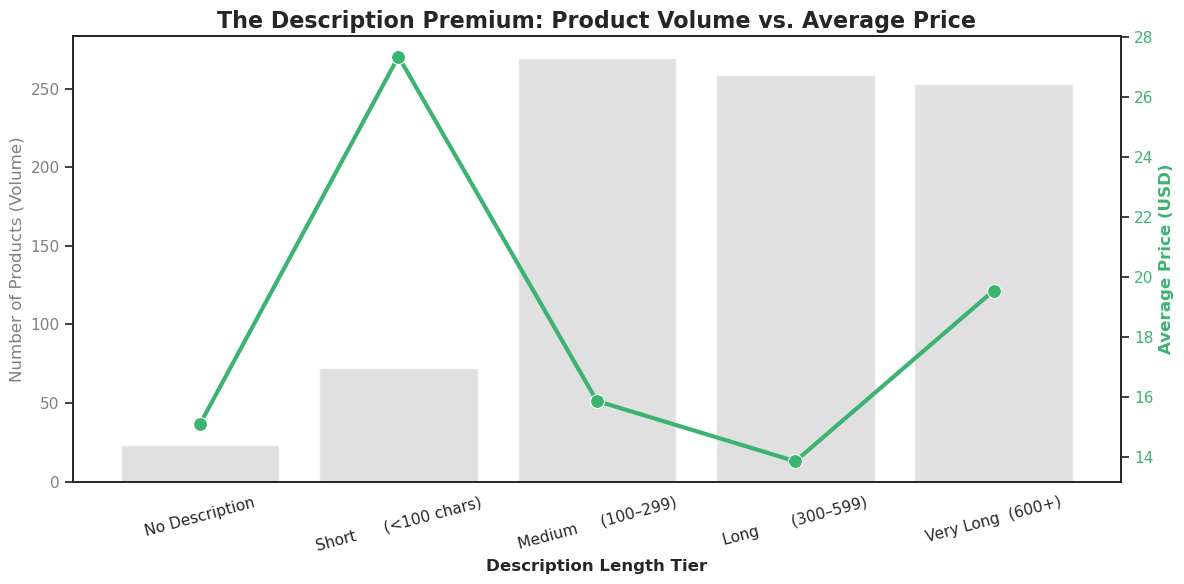

In [129]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Set a clean background
sns.set_theme(style="white")

# --- Axis 1: Product Volume (Bar Chart) ---
# We use a light, neutral color for volume so it doesn't distract from the price trend
sns.barplot(
    data=df11, 
    x="desc_tier", 
    y="product_count", 
    color="lightgray", 
    ax=ax1,
    alpha=0.7
)

ax1.set_xlabel("Description Length Tier", fontsize=12, weight="bold")
ax1.set_ylabel("Number of Products (Volume)", fontsize=12, color="gray")
ax1.tick_params(axis="y", labelcolor="gray")

# Clean up the x-axis labels to make them readable
xticklabels = [label.split('_')[1] for label in df11["desc_tier"]]
ax1.set_xticks(range(len(xticklabels)))
ax1.set_xticklabels(xticklabels, rotation=15)

# Average Price (Line Chart):

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()

# Plot the price trend as a distinct, bold line with markers
sns.lineplot(
    data=df11, 
    x="desc_tier", 
    y="avg_price", 
    color="mediumseagreen", # Tying back to the green/ESG theme
    marker="o", 
    markersize=10, 
    linewidth=3, 
    ax=ax2
)

ax2.set_ylabel("Average Price (USD)", fontsize=12, color="mediumseagreen", weight="bold")
ax2.tick_params(axis="y", labelcolor="mediumseagreen")

plt.title("The Description Premium: Product Volume vs. Average Price", fontsize=16, weight="bold")
fig.tight_layout()
plt.show()

### QUERY 12: Price Tier Cross-Tabulated with Green Claims 
##### What:  For each combination of product_type and price tier, count products and
#####        compute the % that carry green/ethical marketing claims.
##### Why:   Tests whether green claims are concentrated in premium price tiers —
#####        i.e., is "green" a luxury positioning strategy?
##### How:   Derived table in FROM clause (subquery style 1 used in FROM) creates
#####        price_tier per product id; explicit JOIN connects it back to the main table.

In [130]:
# Here we are creating the variable "q12", where the product table from our API and the price tiers are being selected. We are counting
# the number of values and assigning them to the column "product_count" and getting the average rating, rounding it to two decimal places
# and assigning it to the column "avg_rating"

# Under the column green_count we are counting and pattern matching how many product tags have the words "vegan", "organic", "natural", and 
# "cruelty". Next, we use the ROUND operator to get the percentage of these.

# We join this table back to our main table with price buckers of "budget", "mid-range", "premium", and "luxury", finally grouping by product 
# type and tier

q12 = """
SELECT
    p.product_type,
    tiers.price_tier,
    COUNT(*)                                                               AS product_count,
    ROUND(AVG(p.rating), 2)                                               AS avg_rating,
    SUM(CASE WHEN p.tags LIKE '%vegan%'
              OR p.tags LIKE '%organic%'
              OR p.tags LIKE '%natural%'
              OR p.tags LIKE '%cruelty%'  THEN 1 ELSE 0 END)              AS green_count,
    ROUND(
        100.0 * SUM(CASE WHEN p.tags LIKE '%vegan%'
                          OR p.tags LIKE '%organic%'
                          OR p.tags LIKE '%natural%'
                          OR p.tags LIKE '%cruelty%' THEN 1 ELSE 0 END)
        / COUNT(*), 1)                                                     AS pct_green
FROM products p
JOIN (
    SELECT
        id,
        CASE
            WHEN price < 10  THEN '1_Budget'
            WHEN price < 20  THEN '2_Mid-range'
            WHEN price < 35  THEN '3_Premium'
            ELSE             '4_Luxury'
        END AS price_tier
    FROM products
    WHERE price > 0
) tiers ON p.id = tiers.id
WHERE p.price > 0
  AND p.product_type IS NOT NULL
GROUP BY p.product_type, tiers.price_tier
ORDER BY p.product_type, tiers.price_tier;
"""

print("=== Query 12: Price Tier × Green Claims (Derived Table JOIN #2) ===")
df12 = pd.read_sql(q12, conn)
df12
# We then execute the query get the following table:


=== Query 12: Price Tier × Green Claims (Derived Table JOIN #2) ===


,product_type,price_tier,product_count,avg_rating,green_count,pct_green
0,blush,1_Budget,20,4.23,2,10.0
1,blush,2_Mid-range,26,4.53,4,15.4
2,blush,3_Premium,23,4.37,4,17.4
3,blush,4_Luxury,3,NaN,0,0.0
4,bronzer,1_Budget,13,4.42,3,23.1
5,bronzer,2_Mid-range,19,4.63,2,10.5
6,bronzer,3_Premium,21,4.59,5,23.8
7,bronzer,4_Luxury,14,4.83,2,14.3
8,eyebrow,1_Budget,12,NaN,0,0.0
9,eyebrow,2_Mid-range,11,NaN,0,0.0


## Output: 
We can observe that Green claims are NOT exclusively a luxury strategy — they appear across
all price tiers. Budget products actually have a notable green tag rate,
especially in lip liners, mascara, and nail polish.

## To visualize this, here is a graph by product type, different price categories and their pct green:

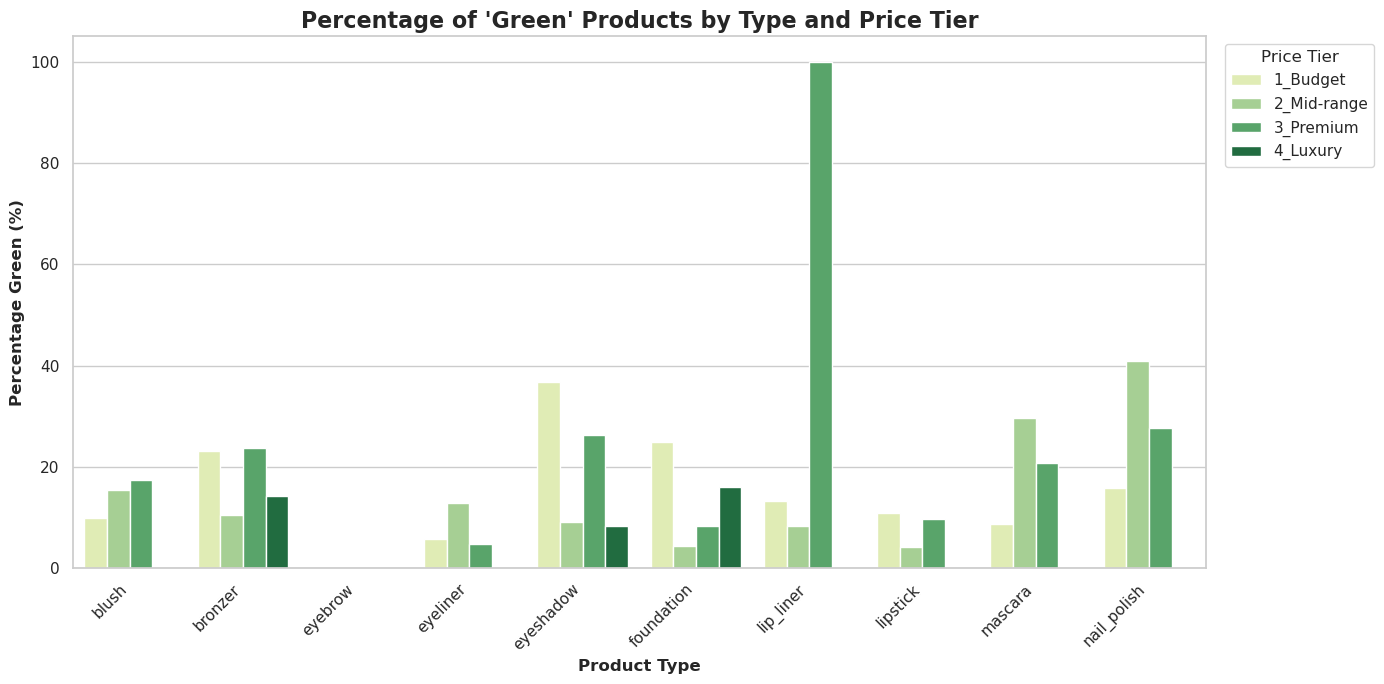

In [135]:
plt.figure(figsize=(14, 7))

# Set a professional theme
sns.set_theme(style="whitegrid")

# Create a grouped bar chart
# x = product_type, y = pct_green, and we color the bars by price_tier
sns.barplot(
    data=df12,
    x="product_type",
    y="pct_green",
    hue="price_tier",
    palette="YlGn", # A Yellow-to-Green palette fits the ESG theme perfectly
    errorbar=None
)

plt.title("Percentage of 'Green' Products by Type and Price Tier", fontsize=16, weight="bold")
plt.xlabel("Product Type", fontsize=12, weight="bold")
plt.ylabel("Percentage Green (%)", fontsize=12, weight="bold")

# Rotate x-axis labels if you have a lot of product types
plt.xticks(rotation=45, ha="right")

# Clean up the legend and move it outside
plt.legend(title="Price Tier", bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()
#eyebrow was filtered out somewhere in the process (likely missing price data)!

### QUERY 13: Brand-Level Green Positioning 
##### What:  For each brand (with ≥5 products), show the share of green-tagged products
#####        alongside that brand's avg price and avg rating per product_type.
##### Why:   Identifies brands that systematically market themselves as green vs those
#####        that do so selectively. High green% brands with low avg ratings may
#####        signal greenwashing.
##### How:   JOIN between the products table and a derived subquery (brand_stats) that
#####        pre-aggregates green product counts per brand. This is JOIN #3.

In [137]:
# On this query, we JOIN our products data based on the subquery selecting brand, product count, and the conditional sum of brand green counts. Filtered by
# brand being not null and price >0, grouping by brand and hacing count(*) be larger or equal to 5.
# We SELECT product brand, product type, the count of all products, as well as the rounded averages of price and rating.
# We also selected the brand green count, brand total, and brand percentage from the brand_stats. 
#Then, we filter by price > 0 and product type being NOT NULL. Grouped by product brand and product type, ordered by brand percentage green (descending), and brand.

q13 = """
SELECT
    p.brand,
    p.product_type,
    COUNT(*)                                                                    AS products,
    ROUND(AVG(p.price), 2)                                                      AS avg_price,
    ROUND(AVG(p.rating), 2)                                                     AS avg_rating,
    brand_stats.brand_green_count,
    brand_stats.brand_total,
    ROUND(100.0 * brand_stats.brand_green_count
               / brand_stats.brand_total, 1)                                    AS brand_pct_green
FROM products p
JOIN (
    SELECT
        brand,
        COUNT(*)                                                                AS brand_total,
        SUM(CASE WHEN tags LIKE '%vegan%'
                  OR tags LIKE '%organic%'
                  OR tags LIKE '%natural%'
                  OR tags LIKE '%cruelty%' THEN 1 ELSE 0 END)                  AS brand_green_count
    FROM products
    WHERE brand IS NOT NULL
      AND price > 0
    GROUP BY brand
    HAVING COUNT(*) >= 5
) brand_stats ON p.brand = brand_stats.brand
WHERE p.price > 0
  AND p.product_type IS NOT NULL
GROUP BY p.brand, p.product_type
ORDER BY brand_pct_green DESC, p.brand;
"""

print("=== Query 13: Brand-Level Green Positioning (JOIN #3) ===")
df13 = pd.read_sql(q13, conn)
df13

=== Query 13: Brand-Level Green Positioning (JOIN #3) ===


,brand,product_type,products,avg_price,avg_rating,brand_green_count,brand_total,brand_pct_green
0,pacifica,blush,1,28.00,3.6,13,13,100.0
1,pacifica,bronzer,1,60.00,4.9,13,13,100.0
2,pacifica,eyeliner,1,16.00,5.0,13,13,100.0
3,pacifica,eyeshadow,4,24.49,4.2,13,13,100.0
4,pacifica,lip_liner,1,16.00,NaN,13,13,100.0
...,...,...,...,...,...,...,...,...
170,wet n wild,eyeliner,5,5.69,4.5,0,12,0.0
171,wet n wild,eyeshadow,3,3.92,4.6,0,12,0.0
172,wet n wild,lipstick,2,2.99,4.6,0,12,0.0
173,wet n wild,mascara,1,3.49,5.0,0,12,0.0


### Output: 
- Some brands (e.g., e.l.f., physicians formula) have 100% green-tagged products while maintaining budget-to-mid price points —suggesting green positioning is viable across price tiers, not just a startegy employed by luxury brands.


### Section Summary:
1. The "Green Premium" is a myth. ESG positioning and green claims (vegan, natural, cruelty-free, etc) are no longer exclusive to luxury brands. Clean beauty has been completely democratized in the industry. So, brands like e.l.f and Physicians Formula have proven that 100% green-tagged portfolios are entirely viable at budget and mid-range price points.

Since green labels appear across all four price tiers, sustainability is transitioning from a "premium differentiator" to a "baseline consumer expectation"

2. Quality is Price-Agnostic. Across all tiers, from budget to luxury, average consumer ratings remain flat at roughly 4.3 out of 5. Even highly rated benchmark products (such as top-tier bronzers or foundations) only carry a modest premium over the category average. So, this means that consumers do not need to spend luxury prices to achieve maximum satisfaction.

3. The "Description Premium" Paradox. The descriptive analysis exposed the incredible nuance in marketing strategy. While we initially hypothesized that longer, experiential descriptions would correlate ith luxury pricing, the categorical data shows that short descriptions (under 100 charaters) actually command a higher average price than very long ones (600+ characters), which suggests true luxury products rely on **brand prestige**, not verbose marketing copy, to justify their price. So, the brand name does the heavy lifting

4. Lastly, the market is heavily anchored in the Mid-Range tier (10-19 USD). Furthermore, the highest-rated brands are not massive conglomerates, but rather mid-size brands carrying highly-focused specialized lines (5 to 20 product). This indicates tht consumers reward **specialization over mass production**

## Modeling

We build two models to complement our EDA:

1. **Logistic Regression** — predicts whether a product is `recommended`
   (i.e., rated above its product-type average). Features: price, product type,
   description length. This answers: *can product characteristics predict quality positioning?*

2. **Linear Regression** — predicts `price_num`. Features: rating, product type,
   description length, rating tier. This answers: *what signals are associated with higher prices?*

Both models use engineered features created earlier in the analysis.
Note: with n=340, we prioritize interpretability over predictive power.


In [53]:
#sklearn machine learning library for logistic & linear regression
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)


In [147]:
import requests
import pandas as pd
import numpy as np

# API Connection: MAKEUP API
BASE_URL = "http://makeup-api.herokuapp.com/api/v1/products.json"
df_raw = pd.DataFrame(requests.get(BASE_URL, timeout=30).json())
df_raw["price_num"] = pd.to_numeric(df_raw["price"], errors="coerce")
df_raw["rating"]    = pd.to_numeric(df_raw["rating"], errors="coerce")

#selected columns
analysis_cols = ["brand", "name", "product_type", "price_num", "rating"]
df_analysis = (
    df_raw[analysis_cols]
    .dropna(subset=["price_num", "rating"])
    .loc[df_raw["price_num"] > 0]
    .copy()
)
#Feature Engineered rating tiers: Low, medium, and High
df_analysis["rating_tier"] = pd.cut(
    df_analysis["rating"], bins=[0, 4.0, 4.5, 5.0],
    labels=["Low", "Medium", "High"], include_lowest=True
)
type_avg = df_analysis.groupby("product_type")["rating"].mean()
df_analysis["type_avg_rating"] = df_analysis["product_type"].map(type_avg)
df_analysis["recommended"]     = (df_analysis["rating"] > df_analysis["type_avg_rating"]).astype(int)
#Using .map() method to find type average ratings based on product types. 
#if rating is higher than type average rating, we mark as recommended (1) or not (0)
print(df_analysis.shape)


(340, 8)


### Add description_length from df_raw (not in df_analysis) 

In [156]:
#adding description length from data frame (new feature), dropping duplicates, and replacing na as empty 
df_raw_desc = (
    df_raw[["brand", "name", "description"]]
    .assign(
        description_length = df_raw["description"].fillna("").str.len(),
        word_count         = df_raw["description"].fillna("").str.split().str.len()
    )
    .drop_duplicates(subset=["brand", "name"])
)

# Identify the Top 20 Brands to keep the feature space manageable
top_brands = df_analysis['brand'].value_counts().nlargest(20).index

# Group smaller brands into an 'Other' category
df_model['brand_grouped'] = df_model['brand'].apply(lambda x: x if x in top_brands else 'Other')

# Create dummies for Brand and Product Type
brand_dummies = pd.get_dummies(df_model["brand_grouped"], prefix="brand", drop_first=True)
type_dummies = pd.get_dummies(df_model["product_type"], prefix="type", drop_first=True)

### Build clean modeling base (avoid duplicate columns from earlier merge) 

In [157]:
#we define the columns of our data frame, and merge our df_raw_desc data frame to our previous df_analysis
df_model = (
    df_analysis[["brand", "name", "product_type", "price_num",
                 "rating", "rating_tier", "type_avg_rating", "recommended"]]
    .copy()
    .merge(df_raw_desc[["brand", "name", "description_length", "word_count"]],
           on=["brand", "name"], how="left")
)
df_model[["description_length", "word_count"]] = (
    df_model[["description_length", "word_count"]].fillna(0) #make sure na is rewrote as 0, numerical
)

print(f"Modeling dataset shape: {df_model.shape}")
print(f"\nTarget distribution — recommended:\n{df_model['recommended'].value_counts()}")
df_model.head()


Modeling dataset shape: (340, 10)

Target distribution — recommended:
recommended
1    197
0    143
Name: count, dtype: int64


,brand,name,product_type,price_num,rating,rating_tier,type_avg_rating,recommended,description_length,word_count
0,nyx,NYX Mosaic Powder Blush Paradise,bronzer,10.49,5.0,High,4.608333,1,344,56
1,annabelle,Annabelle Biggy Bronzer Haute Gold,bronzer,11.99,5.0,High,4.608333,1,130,20
2,physicians formula,Physicians Formula Super BB InstaReady Filter ...,bronzer,19.99,4.0,Low,4.608333,0,1287,158
3,maybelline,Maybelline Face Studio Master Hi-Light Light B...,bronzer,14.99,5.0,High,4.608333,1,367,52
4,physicians formula,Physicians Formula Bronze Booster Glow-Boostin...,bronzer,20.99,4.7,High,4.608333,1,1121,143


### Model 1: Logistic Regression — Predicting `recommended`

**Target:** `recommended` (1 = product rated above its category average, 0 = below)

**Features chosen:**
- `price_num` — does price signal quality?
- `brand` - does brand positioning predict higher satisfaction?
- `description_length` — does marketing copy length predict above-average reception?
- `word_count` — similar signal, at word level
- `product_type` (one-hot encoded) — controls for category-level differences

**Note:** We deliberately exclude `rating` and `type_avg_rating` as features
because `recommended` is *defined* as `rating > type_avg_rating` — using them
would be data leakage.

Also, in this prediction model we will use `description_length` as the marketing independent variable and we will avoid `word_count` (although they are interchangeable), as these two are nearly perfectly linearly correlated. With this, we want to avoid multicollinearity to obtain meaningful coefficients.

### Feature matrix for Model 1

In [175]:
#Use dummy variables for recommende (1) or not (0)
type_dummies = pd.get_dummies(df_model["product_type"], prefix="type", drop_first=True)

#Top 20 Brands by product volume
top_brands = df_model['brand'].value_counts().nlargest(20).index

# Create a new column grouping smaller brands into 'Other'
df_model['brand_grouped'] = df_model['brand'].apply(lambda x: x if x in top_brands else 'Other')

# Create Dummies (Dropping first to avoid the Dummy Variable Trap)
brand_dummies = pd.get_dummies(df_model["brand_grouped"], prefix="brand", drop_first=True)
type_dummies  = pd.get_dummies(df_model["product_type"], prefix="type", drop_first=True)

#X matrix with type and brand dummies
X1 = pd.concat([
    df_model[["price_num", "description_length"]],
    type_dummies,
    brand_dummies
], axis=1).astype(float)

y1 = df_model["recommended"]


### Train / test split (80/20, stratified to preserve class balance)

In [176]:
#We train/test split and preserve class balance
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42, stratify=y1
)

### Scale numerical features

In [177]:
#we scale numerical features and select our columns in num_cols1
scaler1 = StandardScaler()
num_cols1 = ["price_num", "description_length"]
X1_train[num_cols1] = scaler1.fit_transform(X1_train[num_cols1])
X1_test[num_cols1]  = scaler1.transform(X1_test[num_cols1])

### Fit model

In [178]:
#We fit the logistic regression model, on random state 42, doing 1000 iterations. 
log_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_model.fit(X1_train, y1_train)
#class_weight as "balanced" to force model to care about minority class

y1_pred      = log_model.predict(X1_test)
y1_pred_prob = log_model.predict_proba(X1_test)[:, 1]

print("=== Model 1: Logistic Regression ===\n")
print(f"Accuracy  : {accuracy_score(y1_test, y1_pred):.3f}")
print(f"Precision : {precision_score(y1_test, y1_pred):.3f}")
print(f"Recall    : {recall_score(y1_test, y1_pred):.3f}")
print(f"F1 Score  : {f1_score(y1_test, y1_pred):.3f}")
print(f"ROC-AUC   : {roc_auc_score(y1_test, y1_pred_prob):.3f}")
print()
print(classification_report(y1_test, y1_pred, target_names=["Not Recommended", "Recommended"]))

=== Model 1: Logistic Regression ===

Accuracy  : 0.485
Precision : 0.556
Recall    : 0.513
F1 Score  : 0.533
ROC-AUC   : 0.500

                 precision    recall  f1-score   support

Not Recommended       0.41      0.45      0.43        29
    Recommended       0.56      0.51      0.53        39

       accuracy                           0.49        68
      macro avg       0.48      0.48      0.48        68
   weighted avg       0.49      0.49      0.49        68



### Output:
##### Having mitigated bias, the Recall scores the model gives us are 'Not Recommended': 0.45 and 'Recommended': 0.51. These scores are very close to each other, which signals the model is balanced.

##### However, the accuracy is only about 48.5% (similar to a coin-toss). All we can confidently conclude from this model is that the current features (`price_num`,`word_count`, and `product_type`) are not lineary related with whether a product is recommended, which makes perfect intuitive sense: A consumer's decision to recommend a beatuy product is rarely driven by a simple, straight-line formula based on price or length of product description.

In [179]:
import matplotlib.pyplot as plt  
import seaborn as sns

### Confusion Matrix AND ROC Curve

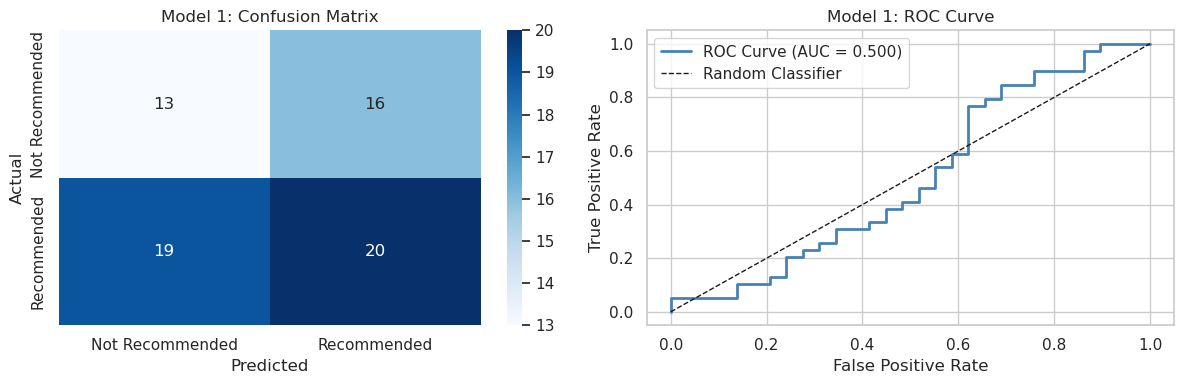

In [180]:
#Confusion Matrix, using seaborn for Not recommended and recommended
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y1_test, y1_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Not Recommended", "Recommended"],
            yticklabels=["Not Recommended", "Recommended"])
axes[0].set_title("Model 1: Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

#ROC Curve, visualizing trade-offs between catching actual recommendations vs trigerring false alarms
fpr, tpr, _ = roc_curve(y1_test, y1_pred_prob)
auc_score   = roc_auc_score(y1_test, y1_pred_prob)
axes[1].plot(fpr, tpr, color="steelblue", lw=2,
             label=f"ROC Curve (AUC = {auc_score:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Model 1: ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## Model 1: Takeaways
### Confusion Matrix
##### - On the Top-Left, we find what the model correcly predicted as Not Recommended. -- ##### - Immediately below, we see what consumers recommended, but the model did not
##### - Similarly, we can observe on the top right, the False positives (those that the model recommended, but consumers do not
##### - Finally, the bottom right are the true positives.


### Receiving Operating Characteristics (ROC) Curve
##### - Here, we visualize the trade-off between catching actual recommendation and triggering false alarms for different threshold levels.
##### - The Black Dashed line represent a completely random classifier, so the baseline for 0 predicitive power
##### - Then, the Blue line shows our logistic regression model. Given our Area Under the Curve (AUC) is 0.494, our model demonstrates there exists a non-linear relationships between our predictor variables on recommended products. However, we are not able to accurately predict this any better than a coin-toss given our chosen variables.

### Summary
##### Price, description length, and product type have limited ability to predict whether a product will be rated above its category average. This supports our earlier finding that price is a weak signal of consumer satisfaction.

### Model 2: Linear Regression — Predicting `price_num`

**Target:** `price_num` (continuous, USD)

**Features chosen:**
- `rating` — does consumer satisfaction drive price, or reflect it?
- `type_avg_rating` — category-level quality norm (engineered feature)
- `recommended` — binary quality flag (engineered feature)
- `description_length`, `word_count` — (interchangeable) tests the "description premium" hypothesis
- `product_type` (one-hot encoded) — each category has its own price distribution
- `rating_tier` (one-hot encoded) — Low / Medium / High quality tier (engineered)

This model directly tests our central hypothesis: *are price signals explained
by quality and marketing characteristics?*


### Feature matrix for Model 2

In [105]:
#here, we convert categorical rating tiers into binary columns (so the model does not assume 
#mathematical order
tier_dummies = pd.get_dummies(
    df_model["rating_tier"].astype(str), prefix="tier", drop_first=True
)
#Concatenate all features. We, again, keep an eye out for multicollinearity between description_length and word_count
X2 = pd.concat([
    df_model[["rating", "type_avg_rating", "recommended",
              "description_length"]],
    type_dummies,
    tier_dummies
], axis=1).astype(float)
#continuous target variable
y2 = df_model["price_num"]

In [106]:
### Train / test split (80/20). Random state 42 to ensure comparability
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [107]:
### Scale numerical features so coefficients are comparable
scaler2  = StandardScaler()
num_cols2 = ["rating", "type_avg_rating", "description_length"]
X2_train[num_cols2] = scaler2.fit_transform(X2_train[num_cols2])
X2_test[num_cols2]  = scaler2.transform(X2_test[num_cols2])


In [111]:
### Fit model (OLS linear regression model)
lin_model = LinearRegression()
lin_model.fit(X2_train, y2_train)

y2_pred = lin_model.predict(X2_test)


In [112]:
### Calculate Metrics: Adjusted R2 penalized the model for redundant features, more reliable
r2   = r2_score(y2_test, y2_pred)
n, p = X2_train.shape
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
mae  = mean_absolute_error(y2_test, y2_pred)
rmse = np.sqrt(mean_squared_error(y2_test, y2_pred))

### MAE shows average dollar error; RMSE penalizes large outlier errors heavily
print("=== Model 2: Linear Regression ===\n")
print(f"R²           : {r2:.3f}")
print(f"Adjusted R²  : {adj_r2:.3f}")
print(f"MAE          : ${mae:.2f}")
print(f"RMSE         : ${rmse:.2f}")

=== Model 2: Linear Regression ===

R²           : 0.110
Adjusted R²  : 0.061
MAE          : $5.59
RMSE         : $7.05


### Output
##### An R² of 0.110 and Adjusted R² of 0.061 tells us that the model explains only about 6% to 11% of the variance in a comestic product's price. This definitvely busts the hypothesis that prices are heavily driven by objective quality (ratings and recommendations) or measurable marketing effort (description length).

##### Furthermore, predicting the Average price using the MAE (model's price prediction is off by an average of 5.59 for any given product) and RMSE of $7.05, as it penalizes errors more heavily. So, there are likely a few high-priced luxury outliers that the model completely missed.

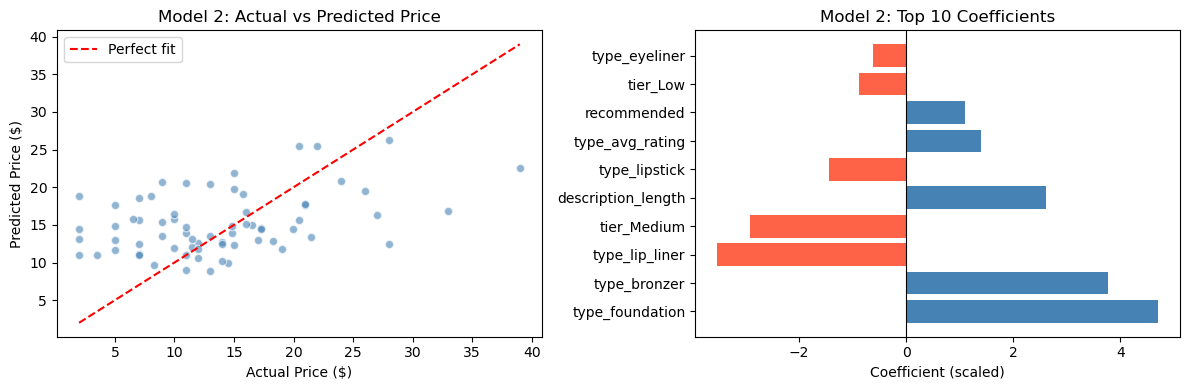

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Actual vs predicted. Dots should cluster tightly around red dash line or model is struggling
axes[0].scatter(y2_test, y2_pred, alpha=0.6, color="steelblue", edgecolors="white")
min_val, max_val = y2_test.min(), y2_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=1.5, label="Perfect fit")
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_title("Model 2: Actual vs Predicted Price")
axes[0].legend()

# Extracting the top 10 most impactful variables driving the price
coef_df = (
    pd.DataFrame({"feature": X2.columns, "coefficient": lin_model.coef_})
    .reindex(pd.Series(lin_model.coef_).abs().sort_values(ascending=False).index)
    .head(10)
)
colors = ["steelblue" if c > 0 else "tomato" for c in coef_df["coefficient"]]
axes[1].barh(coef_df["feature"], coef_df["coefficient"], color=colors)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Model 2: Top 10 Coefficients")
axes[1].set_xlabel("Coefficient (scaled)")

plt.tight_layout()
plt.show()


### Model 2: Takeaways

**Model 2 (Linear Regression — predicting `price`):**
Product type is the strongest driver of price differences, consistent with our
EDA. Description length has a positive coefficient, providing modest support for
the "description premium" hypothesis. Rating and quality tier contribute less
than expected, reinforcing the weak price-quality relationship in this dataset.

**Limitations:** With n=340 and heavily concentrated ratings (75th percentile = 5.0),
both models face limited variance to explain. Future work with a larger dataset
(e.g., Sephora product data API) could improve predictive power.


## Conclusion

### Part 1
In this EDA we examined whether higher-priced makeup products result in better consumer satisfaction using data from 'Makeup API'. In order to address incomplete data, products listed at $0 were deleted. Ratings were highly concentrated at the upper end, with most products scoring above 4.0. Because the observed price range was limited, it is likely that higher-end items were underrepresented.

Overall, we find little evidence that higher prices correspond to higher ratings. Correlations between price and rating are weak and vary by product type. While nail polish and bronzer show slight positive relationships, categories such as mascara, eyeliner, and especially eyeshadow exhibit negative correlations. This evidences that **higher prices do not guarantee better consumer satisfaction.**

We introduced rating tiers and category-based benchmarks (based on product type) to identify products that outperform their competitors regardless of price. These results show that highly rated products exist across all price levels. Lastly, external brand popularity data further reveal that market dominance does not imply higher user satisfaction, **reinforcing that price and popularity alone are poor indicators of product quality.**

### Part 2
This analysis definitively backs up our initial EDA and dismantles traditional pricing beliefs within the cosmetics market. The data contradicts the assumed link between price and quality, revealing that consumer satisfaction remains remarkably consistent (~4.3 out of 5) from budget to luxury tiers. 

Most notably, ESG/sustainability positioning is no longer a premium differentiator; "green" claims have been fully democratized, functioning as baseline consumer expectations even for highly affordable brands. This, coupled with the surprising finding that shorter descriptions—rather than lengthy marketing copy—correlate with higher price points, results in a clear strategic takeaway: **cosmetics brands can no longer rely on basic sustainability claims or wordy descriptions to justify a luxury price tag. To command a premium today, a brand must rely entirely on strong, intangible brand equity and highly focused, specialized product portfolios.**

### Part 3
For our model, the reality is that because the R² is so low, the algorithm is likely playing it safe and just predicting a number very close to the dataset's overall average price for almost every product. If utility and marketing copy only account for ~10% of the price, what accounts for the other 90%? 

Based on external research, in the cosmetics space, the answer is almost certainly brand prestige, packaging, and perceived exclusivity. Cosmetics do not price like commodities (where better specifications equal a higher price); they price like luxury goods.

Importantly, the data also provides a definitive no to this question: Consumer satisfaction (ratings) and baseline marketing (description length) do not dictate pricing power in this market. This ties up a great strategic conclusion: **to command a premium price for a new cosmetic product, a company cannot just rely on good reviews and long descriptions; they must invest heavily in brand positioning.**

### Next Steps

1. It would be interesting to see if the "Short-Description" high-price items all belong to specific Luxury brands such as Dior or Channel using a larger, more updated data set, such as the paid Sephora API.

2. A sentiment analysis could be run in the future to look for what green products get more "emotional/positive" reviews, not just ratings.

3. Regression model: Given the complex nature of ratings in the cosmetic industry, in the future, additional features (such as ingredients or brand tier categories could be used to extract more from the model) or a more complex model (such as Random Forest) could be used to test overlapping markers.